# Eksperimen Perbandingan Hyperparameter (Learning Rate)
## RetinaNet ResNet50-FPN vs YOLOv8s — Deteksi Kardiomegali X-Ray Thorax

Notebook ini menjalankan **ablation study learning rate** untuk kedua model:

| Model | Variabel Pembanding | Skenario |
|---|---|---|
| RetinaNet | LR Head (`lr_head`) | 1e-3 (agresif) / 1e-4 (baseline) / 1e-5 (konservatif) |
| YOLOv8s | `lr0` | 0.01 (agresif) / 0.001 (baseline) / 0.0001 (konservatif) |

**Catatan penting:**
- Semua hyperparameter lain **dijaga konstan** di masing-masing model (batch size, weight decay, optimizer, image size, dst — sama seperti training awal), supaya hanya learning rate yang berubah antar skenario.
- Epoch dibatasi **30** (lebih pendek dari training awal 50 epoch) untuk mempercepat proses eksperimen. Early-stop patience tetap **10**.
- LR backbone RetinaNet diskalakan 10x lebih kecil dari LR head pada tiap skenario, konsisten dengan strategi freeze (epoch 1-3) → unfreeze (epoch 4+) di training awal.
- Notebook ini **mengasumsikan folder `dataset_augmented` sudah ada** (hasil tahap augmentasi offline di notebook training awal kamu). Kalau belum, jalankan dulu cell augmentasi di notebook original sebelum lanjut ke sini.
- Semua model dilatih **dari awal** (fresh pretrained weights) untuk tiap skenario, supaya hasil antar skenario benar-benar independen/adil.

Cek Device

In [12]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU  :", torch.cuda.get_device_name(0))
    print("VRAM :", f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Device: cuda
GPU  : NVIDIA GeForce RTX 4060
VRAM : 8.00 GB


In [19]:
# ============================================================
# CELL 1 — SETUP LENGKAP UNTUK SEMUA VISUALISASI
# ============================================================
%matplotlib inline
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from ultralytics import YOLO

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BASE_DIR       = Path(r'G:\hyperparameter_x-ray_thoraks')
AUG_DIR        = BASE_DIR / 'dataset_augmented'
OUTPUT_DIR     = BASE_DIR / 'outputs'
EXPERIMENT_DIR = OUTPUT_DIR / 'lr_comparison'
AUG_YAML_PATH  = AUG_DIR / 'data.yaml'

AUG_TEST_IMG = AUG_DIR / 'test' / 'images'
AUG_TEST_LBL = AUG_DIR / 'test' / 'labels'

CLASS_NAMES = ['kardiomegali', 'normal']
NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE    = 512
CONF_THRESH = 0.3

# ------------------------------------------------------------
# DATASET RETINANET
# ------------------------------------------------------------
class ThoraxDatasetRetinaNet(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=512):
        self.img_dir   = Path(img_dir)
        self.lbl_dir   = Path(lbl_dir)
        self.img_size  = img_size
        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.jpeg')) +
            list(self.img_dir.glob('*.png'))
        )
        self.base_transform = A.Compose([
            A.Resize(self.img_size, self.img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3, clip=True))

    def __len__(self):
        return len(self.img_files)

    def parse_label(self, line, W, H):
        parts  = line.strip().split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        if len(coords) == 4:
            cx, cy, bw, bh = coords
            x1, y1 = (cx-bw/2)*W, (cy-bh/2)*H
            x2, y2 = (cx+bw/2)*W, (cy+bh/2)*H
        else:
            xs = [coords[i]*W for i in range(0, len(coords), 2)]
            ys = [coords[i]*H for i in range(1, len(coords), 2)]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        return cls_id, max(0,min(x1,W)), max(0,min(y1,H)), max(0,min(x2,W)), max(0,min(y2,H))

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')
        img      = np.array(Image.open(img_path).convert('RGB'))
        H, W     = img.shape[:2]
        boxes, labels = [], []
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                line = line.strip()
                if not line or len(line.split()) < 5: continue
                cls_id, x1, y1, x2, y2 = self.parse_label(line, W, H)
                if x2-x1 >= 2 and y2-y1 >= 2:
                    boxes.append([x1,y1,x2,y2])
                    labels.append(cls_id + 1)
        t          = self.base_transform(image=img, bboxes=boxes, class_labels=labels)
        img_tensor = t['image']
        boxes      = list(t['bboxes'])
        labels     = list(t['class_labels'])
        return img_tensor, {
            'boxes' : torch.tensor(boxes,  dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

def collate_fn(batch):
    batch = [(img, t) for img, t in batch if t['boxes'].shape[0] > 0]
    if len(batch) == 0: return [], []
    return tuple(zip(*batch))

test_ds_r     = ThoraxDatasetRetinaNet(AUG_TEST_IMG, AUG_TEST_LBL, IMG_SIZE)
test_loader_r = DataLoader(test_ds_r, batch_size=4, shuffle=False, collate_fn=collate_fn)

# ------------------------------------------------------------
# FUNGSI RETINANET
# ------------------------------------------------------------
def build_retinanet(num_classes, device=DEVICE):
    model = torchvision.models.detection.retinanet_resnet50_fpn(weights=None)
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256, num_anchors=num_anchors, num_classes=num_classes
    )
    return model.to(device)

@torch.no_grad()
def predict_retinanet(ckpt_path, loader, device, conf_thresh=0.1):
    model = build_retinanet(NUM_CLASSES + 1, device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.eval()
    y_true, y_pred = [], []
    for images, targets in tqdm(loader, desc=ckpt_path.stem, leave=False):
        if len(images) == 0 or len(targets) == 0:
            continue
        images = [img.to(device) for img in images]
        preds  = model(images)
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            if len(gt_boxes) == 0:
                continue
            keep = pred['scores'] >= conf_thresh
            pred_scores, pred_labels = pred['scores'][keep], pred['labels'][keep]
            gt_label   = gt_labels.mode().values.item()
            pred_label = pred_labels[pred_scores.argmax()].item() if len(pred_labels) > 0 else 0
            y_true.append(gt_label)
            y_pred.append(pred_label)
    return y_true, y_pred

# ------------------------------------------------------------
# FUNGSI YOLOv8s
# ------------------------------------------------------------
def get_yolo_predictions(model, img_dir, lbl_dir, conf_thresh=0.3):
    img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)
    image_files = sorted(list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.jpeg')) + list(img_dir.glob('*.png')))
    y_true, y_pred = [], []
    for img_path in tqdm(image_files, desc=img_dir.parent.name, leave=False):
        lbl_path = lbl_dir / f'{img_path.stem}.txt'
        if lbl_path.exists():
            lines = lbl_path.read_text().splitlines()
            ids   = [int(l.split()[0]) for l in lines if len(l.split()) >= 5]
            gt    = max(set(ids), key=ids.count) if ids else 0
        else:
            gt = 0
        result = model.predict(source=str(img_path), conf=conf_thresh, verbose=False)[0]
        if len(result.boxes) > 0:
            scores = result.boxes.conf.cpu().numpy()
            labels = result.boxes.cls.cpu().numpy().astype(int)
            pred   = labels[scores.argmax()]
        else:
            pred = 0
        y_true.append(gt); y_pred.append(pred)
    return y_true, y_pred

def calc_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

def calc_metrics_dict(y_true, y_pred, map50=None, map50_95=None):
    m = calc_metrics(y_true, y_pred)
    m['map50'] = map50
    m['map50_95'] = map50_95
    return m

print('✅ Cell 1 selesai. Lanjut ke Tambahan A.')

✅ Cell 1 selesai. Lanjut ke Tambahan A.


In [20]:
AUG_VALID_IMG = AUG_DIR / 'valid' / 'images'
AUG_VALID_LBL = AUG_DIR / 'valid' / 'labels'

valid_ds_r     = ThoraxDatasetRetinaNet(AUG_VALID_IMG, AUG_VALID_LBL, IMG_SIZE)
valid_loader_r = DataLoader(valid_ds_r, batch_size=4, shuffle=False, collate_fn=collate_fn)

print(f'Valid: {len(valid_ds_r)} gambar | Test: {len(test_ds_r)} gambar')

Valid: 94 gambar | Test: 94 gambar


In [21]:
RETINA_SCENARIOS = ['Aggressive_1e-3', 'Baseline_1e-4', 'Conservative_1e-5']

retina_results = {}
for scenario in RETINA_SCENARIOS:
    ckpt = EXPERIMENT_DIR / f'retinanet_{scenario}_best.pt'
    print(f'{scenario:<22}: {ckpt}  | exists={ckpt.exists()}')
    if not ckpt.exists():
        continue

    y_true_valid, y_pred_valid = predict_retinanet(ckpt, valid_loader_r, DEVICE, CONF_THRESH)
    y_true_test,  y_pred_test  = predict_retinanet(ckpt, test_loader_r,  DEVICE, CONF_THRESH)

    retina_results[scenario] = {
        'cm_valid'      : confusion_matrix(y_true_valid, y_pred_valid, labels=[1, 2]),
        'cm_test'       : confusion_matrix(y_true_test,  y_pred_test,  labels=[1, 2]),
        'metrics_valid' : calc_metrics(y_true_valid, y_pred_valid),
        'metrics_test'  : calc_metrics(y_true_test,  y_pred_test),
    }

print('\n✅ RetinaNet siap:', list(retina_results.keys()))

Aggressive_1e-3       : G:\hyperparameter_x-ray_thoraks\outputs\lr_comparison\retinanet_Aggressive_1e-3_best.pt  | exists=True


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\SenetUser/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 37.4MB/s]


Baseline_1e-4         : G:\hyperparameter_x-ray_thoraks\outputs\lr_comparison\retinanet_Baseline_1e-4_best.pt  | exists=True


Conservative_1e-5     : G:\hyperparameter_x-ray_thoraks\outputs\lr_comparison\retinanet_Conservative_1e-5_best.pt  | exists=True



✅ RetinaNet siap: ['Aggressive_1e-3', 'Baseline_1e-4', 'Conservative_1e-5']


Setup Path & Konfigurasi Eksperimen

In [2]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATH (samakan dengan notebook training awal kamu)
# ============================================================
BASE_DIR       = Path(r'G:\hyperparameter_x-ray_thoraks')
AUG_DIR        = BASE_DIR / 'dataset_augmented'
OUTPUT_DIR     = BASE_DIR / 'outputs'
EXPERIMENT_DIR = OUTPUT_DIR / 'lr_comparison'
YOLO_OUTPUT    = BASE_DIR / 'runs'
AUG_YAML_PATH  = AUG_DIR / 'data.yaml'

AUG_TRAIN_IMG = AUG_DIR / 'train' / 'images'
AUG_TRAIN_LBL = AUG_DIR / 'train' / 'labels'
AUG_VALID_IMG = AUG_DIR / 'valid' / 'images'
AUG_VALID_LBL = AUG_DIR / 'valid' / 'labels'
AUG_TEST_IMG  = AUG_DIR / 'test'  / 'images'
AUG_TEST_LBL  = AUG_DIR / 'test'  / 'labels'

for folder in [OUTPUT_DIR, EXPERIMENT_DIR, YOLO_OUTPUT]:
    folder.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['kardiomegali', 'normal']
NUM_CLASSES = len(CLASS_NAMES)

# ============================================================
# KONFIGURASI EKSPERIMEN PERBANDINGAN LR
# ============================================================
EXP_EPOCHS   = 30     # dibatasi 30 (training awal 50)
EXP_PATIENCE = 10     # early-stop patience, sama seperti training awal
IMG_SIZE     = 512
CONF_THRESH  = 0.3    # threshold confidence saat evaluasi

print('=' * 55)
print('KONFIGURASI EKSPERIMEN PERBANDINGAN LEARNING RATE')
print('=' * 55)
print(f'Epochs          : {EXP_EPOCHS}')
print(f'Patience        : {EXP_PATIENCE}')
print(f'Image size      : {IMG_SIZE}')
print(f'Dataset dir     : {AUG_DIR}')
print(f'Dataset exists  : {AUG_DIR.exists()}')
print(f'Output eksperimen: {EXPERIMENT_DIR}')

KONFIGURASI EKSPERIMEN PERBANDINGAN LEARNING RATE
Epochs          : 30
Patience        : 10
Image size      : 512
Dataset dir     : G:\hyperparameter_x-ray_thoraks\dataset_augmented
Dataset exists  : True
Output eksperimen: G:\hyperparameter_x-ray_thoraks\outputs\lr_comparison


Dataset & DataLoader (RetinaNet)

In [4]:
import cv2
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class ThoraxDatasetRetinaNet(Dataset):
    def __init__(self, img_dir, lbl_dir, img_size=512, augment=False):
        self.img_dir   = Path(img_dir)
        self.lbl_dir   = Path(lbl_dir)
        self.img_size  = img_size
        self.augment   = augment
        self.img_files = sorted(
            list(self.img_dir.glob('*.jpg')) +
            list(self.img_dir.glob('*.jpeg')) +
            list(self.img_dir.glob('*.png'))
        )
        self.aug_transform  = self.build_aug()
        self.base_transform = self.build_base()

    def build_aug(self):
        return A.Compose([
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=5, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.3),
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3, clip=True))

    def build_base(self):
        return A.Compose([
            A.Resize(self.img_size, self.img_size),
            A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'], min_visibility=0.3, clip=True))

    def __len__(self):
        return len(self.img_files)

    def parse_label(self, line, W, H):
        parts  = line.strip().split()
        cls_id = int(parts[0])
        coords = list(map(float, parts[1:]))
        if len(coords) == 4:
            cx, cy, bw, bh = coords
            x1, y1 = (cx-bw/2)*W, (cy-bh/2)*H
            x2, y2 = (cx+bw/2)*W, (cy+bh/2)*H
        else:
            xs = [coords[i]*W for i in range(0, len(coords), 2)]
            ys = [coords[i]*H for i in range(1, len(coords), 2)]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)
        return cls_id, max(0,min(x1,W)), max(0,min(y1,H)), max(0,min(x2,W)), max(0,min(y2,H))

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        lbl_path = self.lbl_dir / (img_path.stem + '.txt')
        img      = np.array(Image.open(img_path).convert('RGB'))
        H, W     = img.shape[:2]
        boxes, labels = [], []
        if lbl_path.exists():
            for line in lbl_path.read_text().splitlines():
                line = line.strip()
                if not line or len(line.split()) < 5: continue
                cls_id, x1, y1, x2, y2 = self.parse_label(line, W, H)
                if x2-x1 >= 2 and y2-y1 >= 2:
                    boxes.append([x1,y1,x2,y2])
                    labels.append(cls_id + 1)
        if self.augment and len(boxes) > 0:
            t      = self.aug_transform(image=img, bboxes=boxes, class_labels=labels)
            img    = t['image']
            boxes  = list(t['bboxes'])
            labels = list(t['class_labels'])
        t          = self.base_transform(image=img, bboxes=boxes, class_labels=labels)
        img_tensor = t['image']
        boxes      = list(t['bboxes'])
        labels     = list(t['class_labels'])
        return img_tensor, {
            'boxes' : torch.tensor(boxes,  dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64)
        }

def collate_fn(batch):
    batch = [(img, t) for img, t in batch if t['boxes'].shape[0] > 0]
    if len(batch) == 0: return [], []
    return tuple(zip(*batch))

train_ds = ThoraxDatasetRetinaNet(AUG_TRAIN_IMG, AUG_TRAIN_LBL, img_size=IMG_SIZE, augment=True)
valid_ds = ThoraxDatasetRetinaNet(AUG_VALID_IMG, AUG_VALID_LBL, img_size=IMG_SIZE, augment=False)
test_ds  = ThoraxDatasetRetinaNet(AUG_TEST_IMG,  AUG_TEST_LBL,  img_size=IMG_SIZE, augment=False)

# batch size dijaga sama seperti training awal (4) -> hanya LR yang jadi variabel
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  collate_fn=collate_fn, num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)

print('=' * 55)
print('DATASET & DATALOADER SIAP')
print('=' * 55)
print(f'Train : {len(train_ds)} gambar | {len(train_loader)} batch')
print(f'Valid : {len(valid_ds)} gambar | {len(valid_loader)} batch')
print(f'Test  : {len(test_ds)}  gambar | {len(test_loader)}  batch')

DATASET & DATALOADER SIAP
Train : 4380 gambar | 1095 batch
Valid : 94 gambar | 24 batch
Test  : 94  gambar | 24  batch


C:\Users\SenetUser\AppData\Local\Temp\ipykernel_14556\1023693229.py:24: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=5, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5),


RetinaNet — Fungsi Build Model, Training, dan Evaluasi per Skenario

In [5]:
import torch.optim as optim
from tqdm import tqdm
import torchvision
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def build_retinanet(num_classes, device=DEVICE):
    """Bangun RetinaNet ResNet50-FPN baru (fresh pretrained COCO) untuk tiap skenario."""
    model = torchvision.models.detection.retinanet_resnet50_fpn(weights='DEFAULT')
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256, num_anchors=num_anchors, num_classes=num_classes
    )
    return model.to(device)

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, count = 0, 0
    pbar = tqdm(loader, leave=False)
    for images, targets in pbar:
        if len(images) == 0: continue
        images  = [img.to(device) for img in images]
        targets = [{'boxes': t['boxes'].to(device), 'labels': t['labels'].to(device)} for t in targets]
        losses  = sum(loss for loss in model(images, targets).values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
        count      += 1
        pbar.set_description(f'Train Loss: {losses.item():.4f}')
    return total_loss / count if count > 0 else 0

@torch.no_grad()
def validate(model, loader, device):
    model.train()  # loss dict hanya tersedia dalam mode train (sesuai kode training awal)
    total_loss, count = 0, 0
    pbar = tqdm(loader, leave=False)
    for images, targets in pbar:
        if len(images) == 0: continue
        images  = [img.to(device) for img in images]
        targets = [{'boxes': t['boxes'].to(device), 'labels': t['labels'].to(device)} for t in targets]
        losses  = sum(loss for loss in model(images, targets).values())
        total_loss += losses.item()
        count      += 1
        pbar.set_description(f'Val Loss: {losses.item():.4f}')
    return total_loss / count if count > 0 else 0

@torch.no_grad()
def evaluate_retinanet(model, loader, device, conf_thresh=0.1):
    y_true, y_pred = [], []
    map_preds, map_targets = [], []
    model.eval()
    for images, targets in tqdm(loader, desc='Evaluasi', leave=False):
        if len(images) == 0 or len(targets) == 0:
            continue
        images = [img.to(device) for img in images]
        preds  = model(images)
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            if len(gt_boxes) == 0:
                continue
            pred_boxes  = pred['boxes']
            pred_scores = pred['scores']
            pred_labels = pred['labels']
            keep        = pred_scores >= conf_thresh
            pred_boxes  = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]
            gt_label   = gt_labels.mode().values.item()
            pred_label = pred_labels[pred_scores.argmax()].item() if len(pred_labels) > 0 else 0
            y_true.append(gt_label)
            y_pred.append(pred_label)
            map_preds.append({'boxes': pred_boxes.cpu(), 'scores': pred_scores.cpu(), 'labels': pred_labels.cpu()})
            map_targets.append({'boxes': gt_boxes.cpu(), 'labels': gt_labels.cpu()})
    metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
    metric.update(map_preds, map_targets)
    map_result = metric.compute()
    return {
        'map50'     : map_result['map_50'].item(),
        'map50_95'  : map_result['map'].item(),
        'precision' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy'  : accuracy_score(y_true, y_pred),
    }

def run_retinanet_experiment(scenario_name, lr_head, lr_backbone, weight_decay=1e-4,
                              epochs=EXP_EPOCHS, patience=EXP_PATIENCE, unfreeze_epoch=4):
    """Latih RetinaNet dari pretrained COCO untuk satu skenario learning rate."""
    print('\n' + '=' * 60)
    print(f'SKENARIO RETINANET: {scenario_name}  (LR head={lr_head:.0e}, LR backbone={lr_backbone:.0e})')
    print('=' * 60)

    model = build_retinanet(num_classes=NUM_CLASSES + 1, device=DEVICE)
    ckpt_path    = EXPERIMENT_DIR / f'retinanet_{scenario_name}_best.pt'
    history_path = EXPERIMENT_DIR / f'retinanet_{scenario_name}_history.csv'

    for param in model.backbone.parameters():
        param.requires_grad = False

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr_head, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    train_losses, val_losses = [], []
    no_improve = 0

    for epoch in range(1, epochs + 1):
        print(f'Epoch {epoch}/{epochs}', end='  ')

        if epoch == unfreeze_epoch:
            print('[UNFREEZE BACKBONE]', end='  ')
            for param in model.backbone.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW([
                {'params': [p for name, p in model.named_parameters() if 'backbone' not in name and p.requires_grad], 'lr': lr_head},
                {'params': model.backbone.parameters(), 'lr': lr_backbone},
            ], weight_decay=weight_decay)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_loss   = validate(model, valid_loader, DEVICE)
        scheduler.step(val_loss)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve    = 0
            torch.save(model.state_dict(), ckpt_path)
            status = 'BEST'
        else:
            no_improve += 1
            status = '-'

        pd.DataFrame({
            'epoch': list(range(1, len(train_losses) + 1)),
            'train_loss': train_losses,
            'val_loss': val_losses
        }).to_csv(history_path, index=False)

        print(f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | Patience: {no_improve}/{patience} | {status}')

        if no_improve >= patience:
            print('EARLY STOPPING')
            break

    # Load bobot terbaik lalu evaluasi di test set
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    metrics = evaluate_retinanet(model, test_loader, DEVICE, CONF_THRESH)

    result = {
        'scenario'      : scenario_name,
        'lr_head'       : lr_head,
        'lr_backbone'   : lr_backbone,
        'epochs_run'    : len(train_losses),
        'best_val_loss' : best_val_loss,
        'map50'         : metrics['map50'],
        'map50_95'      : metrics['map50_95'],
        'precision'     : metrics['precision'],
        'recall'        : metrics['recall'],
        'f1'            : metrics['f1'],
        'accuracy'      : metrics['accuracy'],
        'checkpoint'    : str(ckpt_path),
        'history_csv'   : str(history_path),
    }
    print(f"mAP@0.5: {metrics['map50']:.4f} | mAP@0.5:0.95: {metrics['map50_95']:.4f} | F1: {metrics['f1']:.4f}")
    return result

RetinaNet — Jalankan 3 Skenario Learning Rate

In [6]:
LR_SCENARIOS_RETINA = [
    ('Aggressive_1e-3',   1e-3, 1e-4),   # agresif
    ('Baseline_1e-4',     1e-4, 1e-5),   # baseline (sama seperti training awal)
    ('Conservative_1e-5', 1e-5, 1e-6),   # konservatif
]

retina_results = []
for scenario_name, lr_head, lr_backbone in LR_SCENARIOS_RETINA:
    result = run_retinanet_experiment(scenario_name, lr_head, lr_backbone)
    retina_results.append(result)

retina_results_df = pd.DataFrame(retina_results)
retina_results_df.to_csv(EXPERIMENT_DIR / 'retinanet_lr_comparison_summary.csv', index=False)

print('\n' + '=' * 60)
print('RINGKASAN PERBANDINGAN LEARNING RATE — RETINANET')
print('=' * 60)
print(retina_results_df[['scenario','lr_head','lr_backbone','epochs_run','map50','map50_95','f1']].to_string(index=False))


SKENARIO RETINANET: Aggressive_1e-3  (LR head=1e-03, LR backbone=1e-04)


Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to C:\Users\SenetUser/.cache\torch\hub\checkpoints\retinanet_resnet50_fpn_coco-eeacb38b.pth
100%|██████████| 130M/130M [00:03<00:00, 37.1MB/s] 


Epoch 1/30  

Train: 0.5296 | Val: 0.3570 | Patience: 0/10 | BEST
Epoch 2/30  

Train: 0.3046 | Val: 0.7969 | Patience: 1/10 | -
Epoch 3/30  

...

Train: 0.0512 | Val: 0.1233 | Patience: 8/10 | -
Epoch 28/30  

Train: 0.0500 | Val: 0.1183 | Patience: 9/10 | -
Epoch 29/30  

C:\Users\SenetUser\AppData\Local\Temp\ipykernel_14556\1915762542.py:154: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map_locati

Train: 0.0492 | Val: 0.1138 | Patience: 10/10 | -
EARLY STOPPING


mAP@0.5: 0.9508 | mAP@0.5:0.95: 0.8470 | F1: 0.9362

RINGKASAN PERBANDINGAN LEARNING RATE — RETINANET
         scenario  lr_head  lr_backbone  epochs_run    map50  map50_95       f1
  Aggressive_1e-3  0.00100     0.000100          13 0.803348  0.605867 0.755180
    Baseline_1e-4  0.00010     0.000010          15 0.923660  0.815658 0.870272
Conservative_1e-5  0.00001     0.000001          29 0.950821  0.847023 0.936199


RetinaNet — Visualisasi Perbandingan

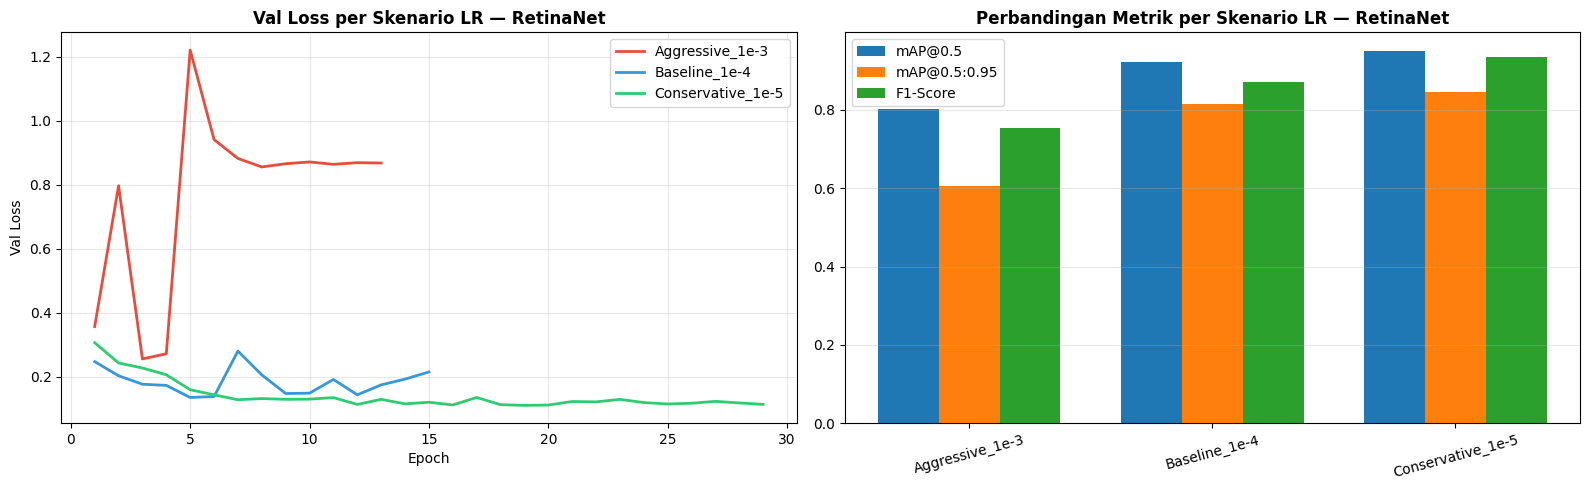

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#E74C3C', '#3498DB', '#2ECC71']

# Kurva val loss overlay antar skenario
for (scenario_name, _, _), color in zip(LR_SCENARIOS_RETINA, colors):
    hist = pd.read_csv(EXPERIMENT_DIR / f'retinanet_{scenario_name}_history.csv')
    axes[0].plot(hist['epoch'], hist['val_loss'], label=scenario_name, color=color, linewidth=2)
axes[0].set_title('Val Loss per Skenario LR — RetinaNet', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Bar chart metrik
x = np.arange(len(retina_results_df))
width = 0.25
axes[1].bar(x - width, retina_results_df['map50'],    width, label='mAP@0.5')
axes[1].bar(x,         retina_results_df['map50_95'], width, label='mAP@0.5:0.95')
axes[1].bar(x + width, retina_results_df['f1'],       width, label='F1-Score')
axes[1].set_xticks(x); axes[1].set_xticklabels(retina_results_df['scenario'], rotation=15)
axes[1].set_title('Perbandingan Metrik per Skenario LR — RetinaNet', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'retinanet_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# REBUILD ARSITEKTUR + LOAD CHECKPOINT RETINANET
# (jalankan ini kalau kernel baru di-restart / retina_model belum ada)
# ============================================================
import torch
import torchvision
from torchvision.models.detection.retinanet import RetinaNetClassificationHead

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RETINA_CKPT = OUTPUT_DIR / 'retinanet_kardio_best.pt'
NUM_CLASSES = 3  # 0=bg, 1=kardiomegali, 2=normal

retina_model = torchvision.models.detection.retinanet_resnet50_fpn(weights=None)  # arsitektur saja, bobot pretrained tidak perlu didownload lagi
num_anchors  = retina_model.head.classification_head.num_anchors
retina_model.head.classification_head = RetinaNetClassificationHead(
    in_channels=256, num_anchors=num_anchors, num_classes=NUM_CLASSES
)

retina_model.load_state_dict(torch.load(RETINA_CKPT, map_location=DEVICE))
retina_model.to(DEVICE)
retina_model.eval()

print('Checkpoint dimuat dari:', RETINA_CKPT)
print('Exists:', RETINA_CKPT.exists())

C:\Users\SenetUser\AppData\Local\Temp\ipykernel_14556\3584897940.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  retina_model.load_state_dict(torch.load(RETINA_CKPT, ma

Checkpoint dimuat dari: G:\hyperparameter_x-ray_thoraks\outputs\retinanet_kardio_best.pt
Exists: True


In [14]:
@torch.no_grad()
def evaluate_retinanet(model, loader, device, conf_thresh=0.1):
    y_true, y_pred = [], []
    map_preds, map_targets = [], []
    model.eval()
    for images, targets in tqdm(loader, desc='Evaluasi', leave=False):
        if len(images) == 0 or len(targets) == 0:
            continue
        images = [img.to(device) for img in images]
        preds  = model(images)
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            if len(gt_boxes) == 0:
                continue
            pred_boxes  = pred['boxes']
            pred_scores = pred['scores']
            pred_labels = pred['labels']
            keep        = pred_scores >= conf_thresh
            pred_boxes  = pred_boxes[keep]
            pred_scores = pred_scores[keep]
            pred_labels = pred_labels[keep]
            gt_label   = gt_labels.mode().values.item()
            pred_label = pred_labels[pred_scores.argmax()].item() if len(pred_labels) > 0 else 0
            y_true.append(gt_label)
            y_pred.append(pred_label)
            map_preds.append({'boxes': pred_boxes.cpu(), 'scores': pred_scores.cpu(), 'labels': pred_labels.cpu()})
            map_targets.append({'boxes': gt_boxes.cpu(), 'labels': gt_labels.cpu()})
    metric = MeanAveragePrecision(iou_type='bbox', class_metrics=True)
    metric.update(map_preds, map_targets)
    map_result = metric.compute()
    return {
        'map50'     : map_result['map_50'].item(),
        'map50_95'  : map_result['map'].item(),
        'precision' : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'    : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'        : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy'  : accuracy_score(y_true, y_pred),
        'y_true'    : y_true,   # ditambahkan
        'y_pred'    : y_pred,   # ditambahkan
    }

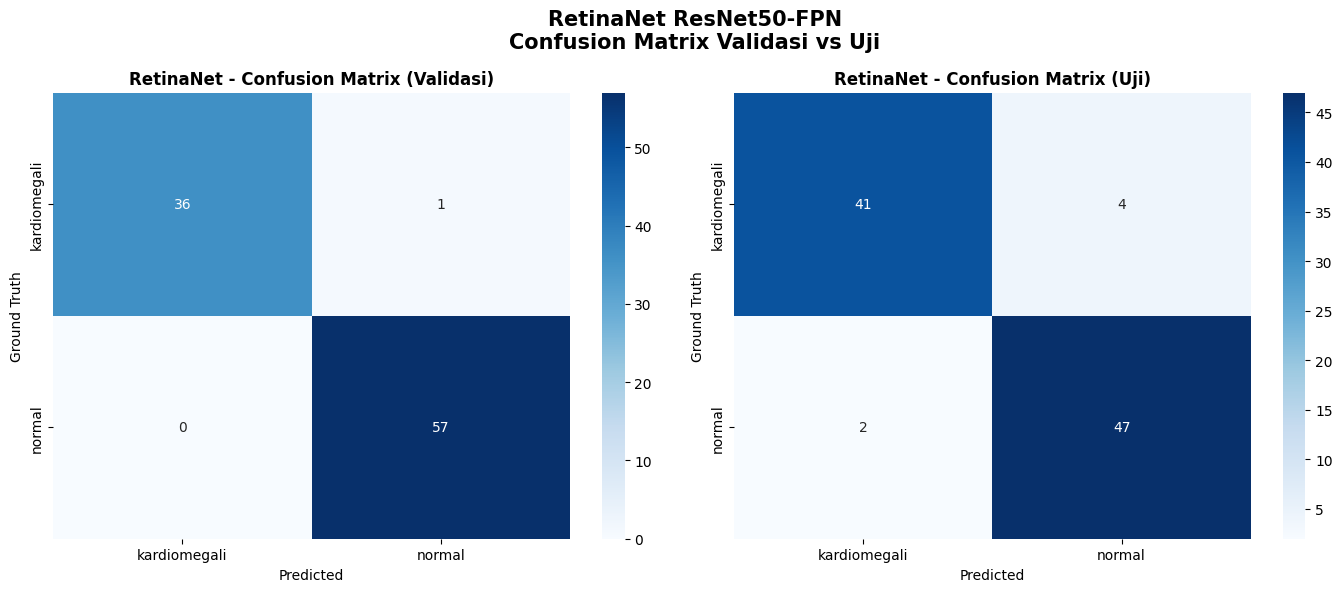

VALIDATION METRICS
Accuracy  : 0.9894
Precision : 0.9895
Recall    : 0.9894
F1-Score  : 0.9893
mAP@0.5   : 1.0000
mAP@0.5:0.95 : 0.8971

TEST METRICS
Accuracy  : 0.9362
Precision : 0.9368
Recall    : 0.9362
F1-Score  : 0.9361
mAP@0.5   : 0.9372
mAP@0.5:0.95 : 0.8349


In [17]:
# ============================================================
# CONFUSION MATRIX RETINANET — VALIDASI vs UJI
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ============================================================
# Evaluasi RetinaNet
# ============================================================
metrics_valid = evaluate_retinanet(
    retina_model,
    valid_loader,
    DEVICE,
    CONF_THRESH
)

metrics_test = evaluate_retinanet(
    retina_model,
    test_loader,
    DEVICE,
    CONF_THRESH
)

# ============================================================
# Ambil Label
# ============================================================
y_true_valid = metrics_valid['y_true']
y_pred_valid = metrics_valid['y_pred']

y_true_test = metrics_test['y_true']
y_pred_test = metrics_test['y_pred']

# ============================================================
# Confusion Matrix
# ============================================================
cm_valid = confusion_matrix(
    y_true_valid,
    y_pred_valid,
    labels=[1,2]
)

cm_test = confusion_matrix(
    y_true_test,
    y_pred_test,
    labels=[1,2]
)

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(14,6))

sns.heatmap(
    cm_valid,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0]
)

axes[0].set_title(
    'RetinaNet - Confusion Matrix (Validasi)',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Ground Truth')

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)

axes[1].set_title(
    'RetinaNet - Confusion Matrix (Uji)',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Ground Truth')

plt.suptitle(
    'RetinaNet ResNet50-FPN\nConfusion Matrix Validasi vs Uji',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "retinanet_confusion_matrix_valid_vs_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Tampilkan Metrik
# ============================================================
print("="*60)
print("VALIDATION METRICS")
print("="*60)
print(f"Accuracy  : {metrics_valid['accuracy']:.4f}")
print(f"Precision : {metrics_valid['precision']:.4f}")
print(f"Recall    : {metrics_valid['recall']:.4f}")
print(f"F1-Score  : {metrics_valid['f1']:.4f}")
print(f"mAP@0.5   : {metrics_valid['map50']:.4f}")
print(f"mAP@0.5:0.95 : {metrics_valid['map50_95']:.4f}")

print()

print("="*60)
print("TEST METRICS")
print("="*60)
print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
print(f"Precision : {metrics_test['precision']:.4f}")
print(f"Recall    : {metrics_test['recall']:.4f}")
print(f"F1-Score  : {metrics_test['f1']:.4f}")
print(f"mAP@0.5   : {metrics_test['map50']:.4f}")
print(f"mAP@0.5:0.95 : {metrics_test['map50_95']:.4f}")

In [18]:
# ============================================================
# TABEL HASIL PERBANDINGAN LEARNING RATE
# ============================================================

comparison_table = retina_results_df.copy()

comparison_table = comparison_table.rename(columns={
    'scenario': 'Scenario',
    'lr_head': 'LR Head',
    'lr_backbone': 'LR Backbone',
    'epochs_run': 'Epoch',
    'map50': 'mAP@0.5',
    'map50_95': 'mAP@0.5:0.95',
    'f1': 'F1-Score'
})

comparison_table['mAP@0.5'] = comparison_table['mAP@0.5'].map(lambda x: f'{x:.4f}')
comparison_table['mAP@0.5:0.95'] = comparison_table['mAP@0.5:0.95'].map(lambda x: f'{x:.4f}')
comparison_table['F1-Score'] = comparison_table['F1-Score'].map(lambda x: f'{x:.4f}')

display(comparison_table)

,Scenario,LR Head,LR Backbone,Epoch,best_val_loss,mAP@0.5,mAP@0.5:0.95,precision,recall,F1-Score,accuracy,checkpoint,history_csv
0,Aggressive_1e-3,0.00100,0.000100,13,0.255804,0.8033,0.6059,0.755213,0.755319,0.7552,0.755319,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...
1,Baseline_1e-4,0.00010,0.000010,15,0.135400,0.9237,0.8157,0.889135,0.872340,0.8703,0.872340,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...
2,Conservative_1e-5,0.00001,0.000001,29,0.110750,0.9508,0.8470,0.937076,0.936170,0.9362,0.936170,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...,G:\hyperparameter_x-ray_thoraks\outputs\lr_com...


YOLOv8s — Verifikasi Library & Path

In [3]:
import ultralytics
from ultralytics import YOLO

print('=' * 55)
print('VERIFIKASI LIBRARY YOLOv8s')
print('=' * 55)
print(f'Ultralytics : {ultralytics.__version__}')
print(f'CUDA        : {torch.cuda.is_available()}')
print(f'\nAUG_YAML_PATH : {AUG_YAML_PATH}')
print(f'Exists        : {AUG_YAML_PATH.exists()}')

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\SenetUser\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
VERIFIKASI LIBRARY YOLOv8s
Ultralytics : 8.4.58
CUDA        : True

AUG_YAML_PATH : G:\hyperparameter_x-ray_thoraks\dataset_augmented\data.yaml
Exists        : True


YOLOv8s — Fungsi Training & Evaluasi per Skenario

In [6]:
# ============================================================
# RUN YOLO EXPERIMENT — DENGAN CONFUSION MATRIX VALIDASI & UJI
# ============================================================
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

def get_yolo_predictions(model, img_dir, lbl_dir, conf_thresh=CONF_THRESH):
    """Prediksi per-gambar (1 label dominan per gambar) untuk keperluan confusion matrix."""
    img_dir, lbl_dir = Path(img_dir), Path(lbl_dir)
    image_files = sorted(
        list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.jpeg')) + list(img_dir.glob('*.png'))
    )
    y_true, y_pred = [], []
    for img_path in tqdm(image_files, desc=f'Prediksi ({img_dir.parent.name})', leave=False):
        lbl_path = lbl_dir / f'{img_path.stem}.txt'
        if lbl_path.exists():
            lines = lbl_path.read_text().splitlines()
            ids   = [int(l.split()[0]) for l in lines if len(l.split()) >= 5]
            gt    = max(set(ids), key=ids.count) if ids else 0
        else:
            gt = 0
        result = model.predict(source=str(img_path), conf=conf_thresh, verbose=False)[0]
        if len(result.boxes) > 0:
            scores = result.boxes.conf.cpu().numpy()
            labels = result.boxes.cls.cpu().numpy().astype(int)
            pred   = labels[scores.argmax()]
        else:
            pred = 0
        y_true.append(gt); y_pred.append(pred)
    return y_true, y_pred


def calc_metrics_dict(y_true, y_pred, map50=None, map50_95=None):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'map50'    : map50,
        'map50_95' : map50_95,
    }


def run_yolo_experiment(scenario_name, lr0, epochs=EXP_EPOCHS, patience=EXP_PATIENCE):
    """Latih YOLOv8s dari pretrained yolov8s.pt untuk satu skenario lr0,
    lalu evaluasi + confusion matrix untuk VALIDASI dan UJI sekaligus."""
    print('\n' + '=' * 60)
    print(f'SKENARIO YOLOv8s: {scenario_name}  (lr0={lr0})')
    print('=' * 60)

    model = YOLO('yolov8s.pt')  # fresh pretrained tiap skenario

    model.train(
        data     = str(AUG_YAML_PATH),
        epochs   = epochs,
        patience = patience,
        batch    = 16,
        imgsz    = IMG_SIZE,
        workers  = 0,
        device   = 0,
        verbose  = True,

        project  = str(EXPERIMENT_DIR / 'yolov8s'),
        name     = scenario_name,
        exist_ok = True,
        save     = True,
        plots    = True,

        optimizer     = 'AdamW',
        lr0           = lr0,
        lrf           = 0.0001,
        weight_decay  = 0.0005,
        warmup_epochs = 3,

        val = True,
    )

    best_model_path = EXPERIMENT_DIR / 'yolov8s' / scenario_name / 'weights' / 'best.pt'
    model_best = YOLO(str(best_model_path))

    # ------------------------------------------------------------
    # mAP resmi dari Ultralytics (validasi & uji terpisah)
    # ------------------------------------------------------------
    val_map  = model_best.val(data=str(AUG_YAML_PATH), split='val',  conf=CONF_THRESH, iou=0.5, plots=False, verbose=False)
    test_map = model_best.val(data=str(AUG_YAML_PATH), split='test', conf=CONF_THRESH, iou=0.5, plots=False, verbose=False)

    # ------------------------------------------------------------
    # Prediksi per-gambar untuk confusion matrix (validasi & uji)
    # ------------------------------------------------------------
    y_true_valid, y_pred_valid = get_yolo_predictions(model_best, AUG_VALID_IMG, AUG_VALID_LBL, CONF_THRESH)
    y_true_test,  y_pred_test  = get_yolo_predictions(model_best, AUG_TEST_IMG,  AUG_TEST_LBL,  CONF_THRESH)

    cm_valid = confusion_matrix(y_true_valid, y_pred_valid, labels=list(range(NUM_CLASSES)))
    cm_test  = confusion_matrix(y_true_test,  y_pred_test,  labels=list(range(NUM_CLASSES)))

    metrics_valid = calc_metrics_dict(y_true_valid, y_pred_valid, float(val_map.box.map50),  float(val_map.box.map))
    metrics_test  = calc_metrics_dict(y_true_test,  y_pred_test,  float(test_map.box.map50), float(test_map.box.map))

    # ------------------------------------------------------------
    # Hasil gabungan (backward-compatible + tambahan valid/test)
    # ------------------------------------------------------------
    result = {
        # -- key lama (dipakai loop skenario & summary table) --
        'scenario'   : scenario_name,
        'lr0'        : lr0,
        'map50'      : metrics_test['map50'],
        'map50_95'   : metrics_test['map50_95'],
        'precision'  : metrics_test['precision'],
        'recall'     : metrics_test['recall'],
        'f1'         : metrics_test['f1'],
        'checkpoint' : str(best_model_path),
        'results_csv': str(EXPERIMENT_DIR / 'yolov8s' / scenario_name / 'results.csv'),

        # -- key baru, sesuai pola RetinaNet --
        'cm_valid'      : cm_valid,
        'cm_test'       : cm_test,
        'metrics_valid' : metrics_valid,
        'metrics_test'  : metrics_test,
        'y_true_valid'  : y_true_valid,
        'y_pred_valid'  : y_pred_valid,
        'y_true_test'   : y_true_test,
        'y_pred_test'   : y_pred_test,
    }

    print(f"[VALID] mAP@0.5: {metrics_valid['map50']:.4f} | mAP@0.5:0.95: {metrics_valid['map50_95']:.4f} | F1: {metrics_valid['f1']:.4f}")
    print(f"[TEST ] mAP@0.5: {metrics_test['map50']:.4f} | mAP@0.5:0.95: {metrics_test['map50_95']:.4f} | F1: {metrics_test['f1']:.4f}")
    return result

YOLOv8s — Jalankan 3 Skenario Learning Rate (lr0)

In [8]:
import yaml

new_yaml_content = {
    'train': str(AUG_DIR / 'train' / 'images').replace('\\', '/'),
    'val'  : str(AUG_DIR / 'valid' / 'images').replace('\\', '/'),
    'test' : str(AUG_DIR / 'test'  / 'images').replace('\\', '/'),
    'nc'   : NUM_CLASSES,
    'names': CLASS_NAMES,
}

with open(AUG_YAML_PATH, 'w') as f:
    yaml.dump(new_yaml_content, f, default_flow_style=False, allow_unicode=True, sort_keys=False)

print("data.yaml diperbaiki ulang:")
with open(AUG_YAML_PATH) as f:
    print(f.read())

data.yaml diperbaiki ulang:
train: G:/hyperparameter_x-ray_thoraks/dataset_augmented/train/images
val: G:/hyperparameter_x-ray_thoraks/dataset_augmented/valid/images
test: G:/hyperparameter_x-ray_thoraks/dataset_augmented/test/images
nc: 2
names:
- kardiomegali
- normal



In [9]:
# ============================================================
# AUTO-CHECK & AUTO-FIX data.yaml SEBELUM TRAINING
# ============================================================
import yaml

with open(AUG_YAML_PATH, 'r') as f:
    current_yaml = yaml.safe_load(f)

expected_train = str(AUG_DIR / 'train' / 'images').replace('\\', '/')
needs_fix = current_yaml.get('train', '').replace('\\', '/') != expected_train

if needs_fix:
    print('⚠️  data.yaml berisi path lama, memperbaiki otomatis...')
    new_yaml_content = {
        'train': str(AUG_DIR / 'train' / 'images').replace('\\', '/'),
        'val'  : str(AUG_DIR / 'valid' / 'images').replace('\\', '/'),
        'test' : str(AUG_DIR / 'test'  / 'images').replace('\\', '/'),
        'nc'   : NUM_CLASSES,
        'names': CLASS_NAMES,
    }
    with open(AUG_YAML_PATH, 'w') as f:
        yaml.dump(new_yaml_content, f, default_flow_style=False, allow_unicode=True, sort_keys=False)
    print('✅ data.yaml sudah diperbaiki.')
else:
    print('✅ data.yaml sudah benar, aman untuk training.')

with open(AUG_YAML_PATH) as f:
    print(f.read())

✅ data.yaml sudah benar, aman untuk training.
train: G:/hyperparameter_x-ray_thoraks/dataset_augmented/train/images
val: G:/hyperparameter_x-ray_thoraks/dataset_augmented/valid/images
test: G:/hyperparameter_x-ray_thoraks/dataset_augmented/test/images
nc: 2
names:
- kardiomegali
- normal



In [10]:
LR_SCENARIOS_YOLO = [
    ('Aggressive_0.01',     0.01),    # agresif
    ('Baseline_0.001',      0.001),   # baseline (sama seperti training awal)
    ('Conservative_0.0001', 0.0001),  # konservatif
]

yolo_results = []
for scenario_name, lr0 in LR_SCENARIOS_YOLO:
    result = run_yolo_experiment(scenario_name, lr0)
    yolo_results.append(result)

# ------------------------------------------------------------
# DataFrame BERSIH untuk CSV/tabel (hanya kolom skalar)
# ------------------------------------------------------------
clean_cols = ['scenario', 'lr0', 'map50', 'map50_95', 'precision', 'recall', 'f1', 'checkpoint', 'results_csv']
yolo_results_df = pd.DataFrame([{k: r[k] for k in clean_cols} for r in yolo_results])
yolo_results_df.to_csv(EXPERIMENT_DIR / 'yolov8s_lr_comparison_summary.csv', index=False)

print('\n' + '=' * 60)
print('RINGKASAN PERBANDINGAN LEARNING RATE — YOLOv8s')
print('=' * 60)
print(yolo_results_df[['scenario','lr0','map50','map50_95','f1']].to_string(index=False))


SKENARIO YOLOv8s: Aggressive_0.01  (lr0=0.01)
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.58  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\hyperparameter_x-ray_thoraks\dataset_augmented\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.0001, mask_ratio=4, max_det=300, mixup

[VALID] mAP@0.5: 0.9542 | mAP@0.5:0.95: 0.8606 | F1: 0.9787
[TEST ] mAP@0.5: 0.9453 | mAP@0.5:0.95: 0.8666 | F1: 0.9359

SKENARIO YOLOv8s: Baseline_0.001  (lr0=0.001)
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.58  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\hyperparameter_x-ray_thoraks\dataset_augmented\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=

[VALID] mAP@0.5: 0.9312 | mAP@0.5:0.95: 0.8346 | F1: 0.8924
[TEST ] mAP@0.5: 0.9001 | mAP@0.5:0.95: 0.8190 | F1: 0.8929

SKENARIO YOLOv8s: Conservative_0.0001  (lr0=0.0001)
New https://pypi.org/project/ultralytics/8.4.115 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.58  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8187MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=G:\hyperparameter_x-ray_thoraks\dataset_augmented\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

[VALID] mAP@0.5: 0.9441 | mAP@0.5:0.95: 0.8453 | F1: 0.9028
[TEST ] mAP@0.5: 0.9132 | mAP@0.5:0.95: 0.8216 | F1: 0.8703

RINGKASAN PERBANDINGAN LEARNING RATE — YOLOv8s
           scenario    lr0    map50  map50_95       f1
    Aggressive_0.01 0.0100 0.945315  0.866590 0.935937
     Baseline_0.001 0.0010 0.900106  0.819019 0.892886
Conservative_0.0001 0.0001 0.913194  0.821609 0.870272


YOLOv8s — Visualisasi Perbandingan

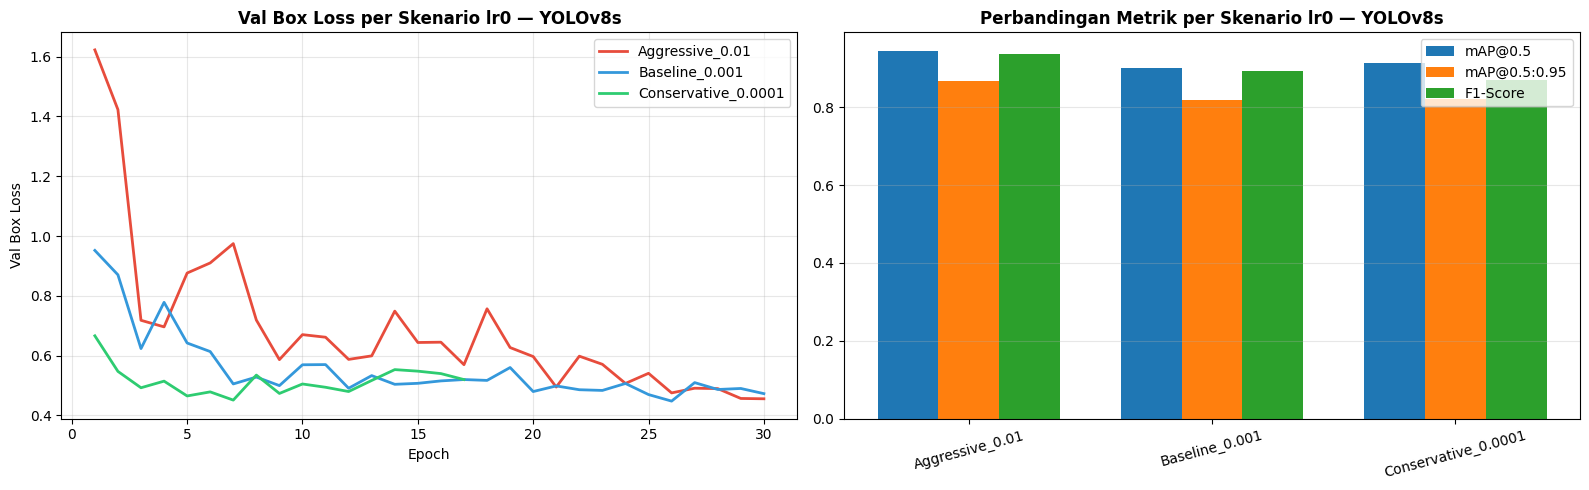

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#E74C3C', '#3498DB', '#2ECC71']

# Kurva val box loss overlay antar skenario (dari results.csv Ultralytics)
for (scenario_name, _), color in zip(LR_SCENARIOS_YOLO, colors):
    csv_path = EXPERIMENT_DIR / 'yolov8s' / scenario_name / 'results.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        val_col = 'val/box_loss' if 'val/box_loss' in df.columns else df.columns[1]
        axes[0].plot(df.index + 1, df[val_col], label=scenario_name, color=color, linewidth=2)
axes[0].set_title('Val Box Loss per Skenario lr0 — YOLOv8s', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Val Box Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Bar chart metrik
x = np.arange(len(yolo_results_df))
width = 0.25
axes[1].bar(x - width, yolo_results_df['map50'],    width, label='mAP@0.5')
axes[1].bar(x,         yolo_results_df['map50_95'], width, label='mAP@0.5:0.95')
axes[1].bar(x + width, yolo_results_df['f1'],       width, label='F1-Score')
axes[1].set_xticks(x); axes[1].set_xticklabels(yolo_results_df['scenario'], rotation=15)
axes[1].set_title('Perbandingan Metrik per Skenario lr0 — YOLOv8s', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'yolov8s_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

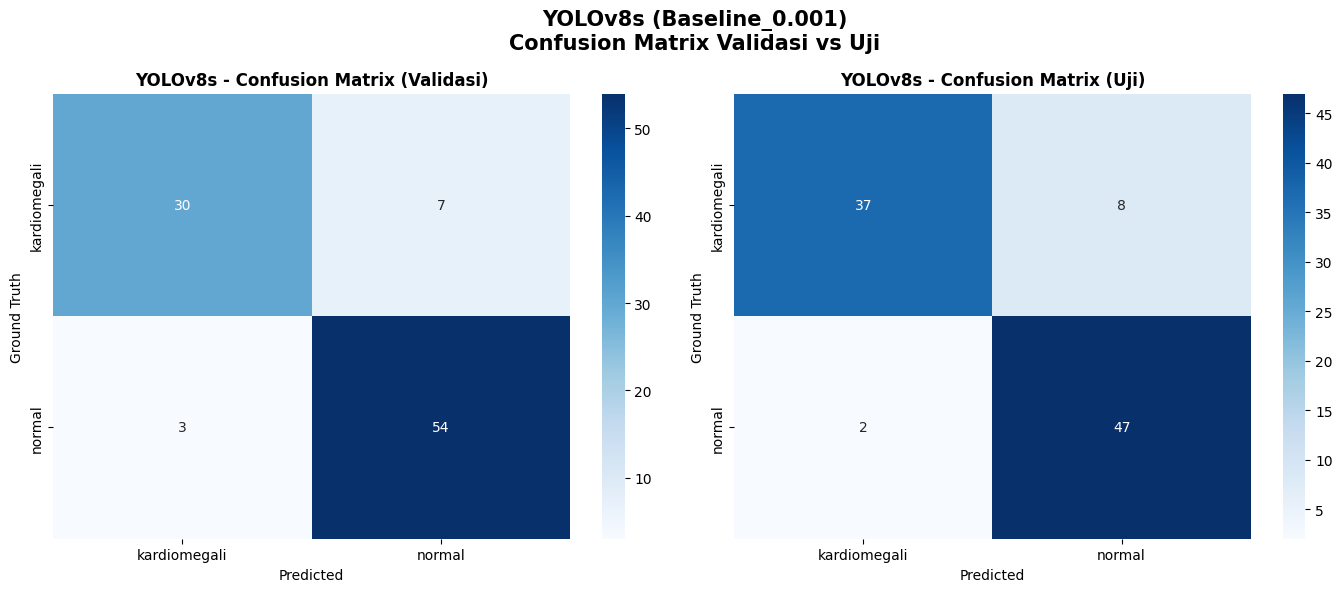

VALIDATION METRICS
Accuracy  : 0.8936
Precision : 0.8946
Recall    : 0.8936
F1-Score  : 0.8924
mAP@0.5   : 0.9312
mAP@0.5:0.95 : 0.8346

TEST METRICS
Accuracy  : 0.8936
Precision : 0.8996
Recall    : 0.8936
F1-Score  : 0.8929
mAP@0.5   : 0.9001
mAP@0.5:0.95 : 0.8190


In [32]:
# ============================================================
# CONFUSION MATRIX YOLOv8s — VALIDASI vs UJI
# ============================================================
SCENARIO_TO_PLOT = 'Baseline_0.001'   # ganti ke 'Aggressive_0.01' atau 'Conservative_0.0001' kalau mau skenario lain

res = yolo_results_dict[SCENARIO_TO_PLOT]

cm_valid = res['cm_valid']
cm_test  = res['cm_test']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    cm_valid,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title(
    'YOLOv8s - Confusion Matrix (Validasi)',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Ground Truth')

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title(
    'YOLOv8s - Confusion Matrix (Uji)',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Ground Truth')

plt.suptitle(
    f'YOLOv8s ({SCENARIO_TO_PLOT})\nConfusion Matrix Validasi vs Uji',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / f'yolov8s_{SCENARIO_TO_PLOT}_confusion_matrix_valid_vs_test.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# Tampilkan Metrik
# ============================================================
metrics_valid = res['metrics_valid']
metrics_test  = res['metrics_test']

print("="*60)
print("VALIDATION METRICS")
print("="*60)
print(f"Accuracy  : {metrics_valid['accuracy']:.4f}")
print(f"Precision : {metrics_valid['precision']:.4f}")
print(f"Recall    : {metrics_valid['recall']:.4f}")
print(f"F1-Score  : {metrics_valid['f1']:.4f}")
print(f"mAP@0.5   : {metrics_valid['map50']:.4f}")
print(f"mAP@0.5:0.95 : {metrics_valid['map50_95']:.4f}")

print()

print("="*60)
print("TEST METRICS")
print("="*60)
print(f"Accuracy  : {metrics_test['accuracy']:.4f}")
print(f"Precision : {metrics_test['precision']:.4f}")
print(f"Recall    : {metrics_test['recall']:.4f}")
print(f"F1-Score  : {metrics_test['f1']:.4f}")
print(f"mAP@0.5   : {metrics_test['map50']:.4f}")
print(f"mAP@0.5:0.95 : {metrics_test['map50_95']:.4f}")

Ringkasan Akhir — Perbandingan Learning Rate RetinaNet vs YOLOv8s

In [22]:
if 'yolo_results' not in dir():
    print('yolo_results tidak ditemukan, reload dari checkpoint tersimpan...')
    YOLO_SCENARIOS = [('Aggressive_0.01', 0.01), ('Baseline_0.001', 0.001), ('Conservative_0.0001', 0.0001)]
    yolo_results = []
    for scenario_name, lr0 in YOLO_SCENARIOS:
        ckpt = EXPERIMENT_DIR / 'yolov8s' / scenario_name / 'weights' / 'best.pt'
        if not ckpt.exists():
            print(f'❌ {scenario_name}: checkpoint tidak ditemukan di {ckpt}')
            continue
        model_best = YOLO(str(ckpt))
        val_map  = model_best.val(data=str(AUG_YAML_PATH), split='val',  conf=CONF_THRESH, plots=False, verbose=False)
        test_map = model_best.val(data=str(AUG_YAML_PATH), split='test', conf=CONF_THRESH, plots=False, verbose=False)
        y_true_valid, y_pred_valid = get_yolo_predictions(model_best, AUG_VALID_IMG, AUG_VALID_LBL, CONF_THRESH)
        y_true_test,  y_pred_test  = get_yolo_predictions(model_best, AUG_TEST_IMG,  AUG_TEST_LBL,  CONF_THRESH)
        yolo_results.append({
            'scenario': scenario_name, 'lr0': lr0,
            'cm_valid': confusion_matrix(y_true_valid, y_pred_valid, labels=list(range(NUM_CLASSES))),
            'cm_test' : confusion_matrix(y_true_test,  y_pred_test,  labels=list(range(NUM_CLASSES))),
            'metrics_valid': calc_metrics_dict(y_true_valid, y_pred_valid, float(val_map.box.map50),  float(val_map.box.map)),
            'metrics_test' : calc_metrics_dict(y_true_test,  y_pred_test,  float(test_map.box.map50), float(test_map.box.map)),
        })
        print(f'✅ {scenario_name} reloaded')
else:
    print('✅ yolo_results sudah ada di memori, tidak perlu reload.')

yolo_results_dict = {r['scenario']: r for r in yolo_results}

✅ yolo_results sudah ada di memori, tidak perlu reload.


Visualisasi Gabungan ke 2 Model 

Confusion Matrix RetinaNet (Validasi vs Uji per Konfigurasi)

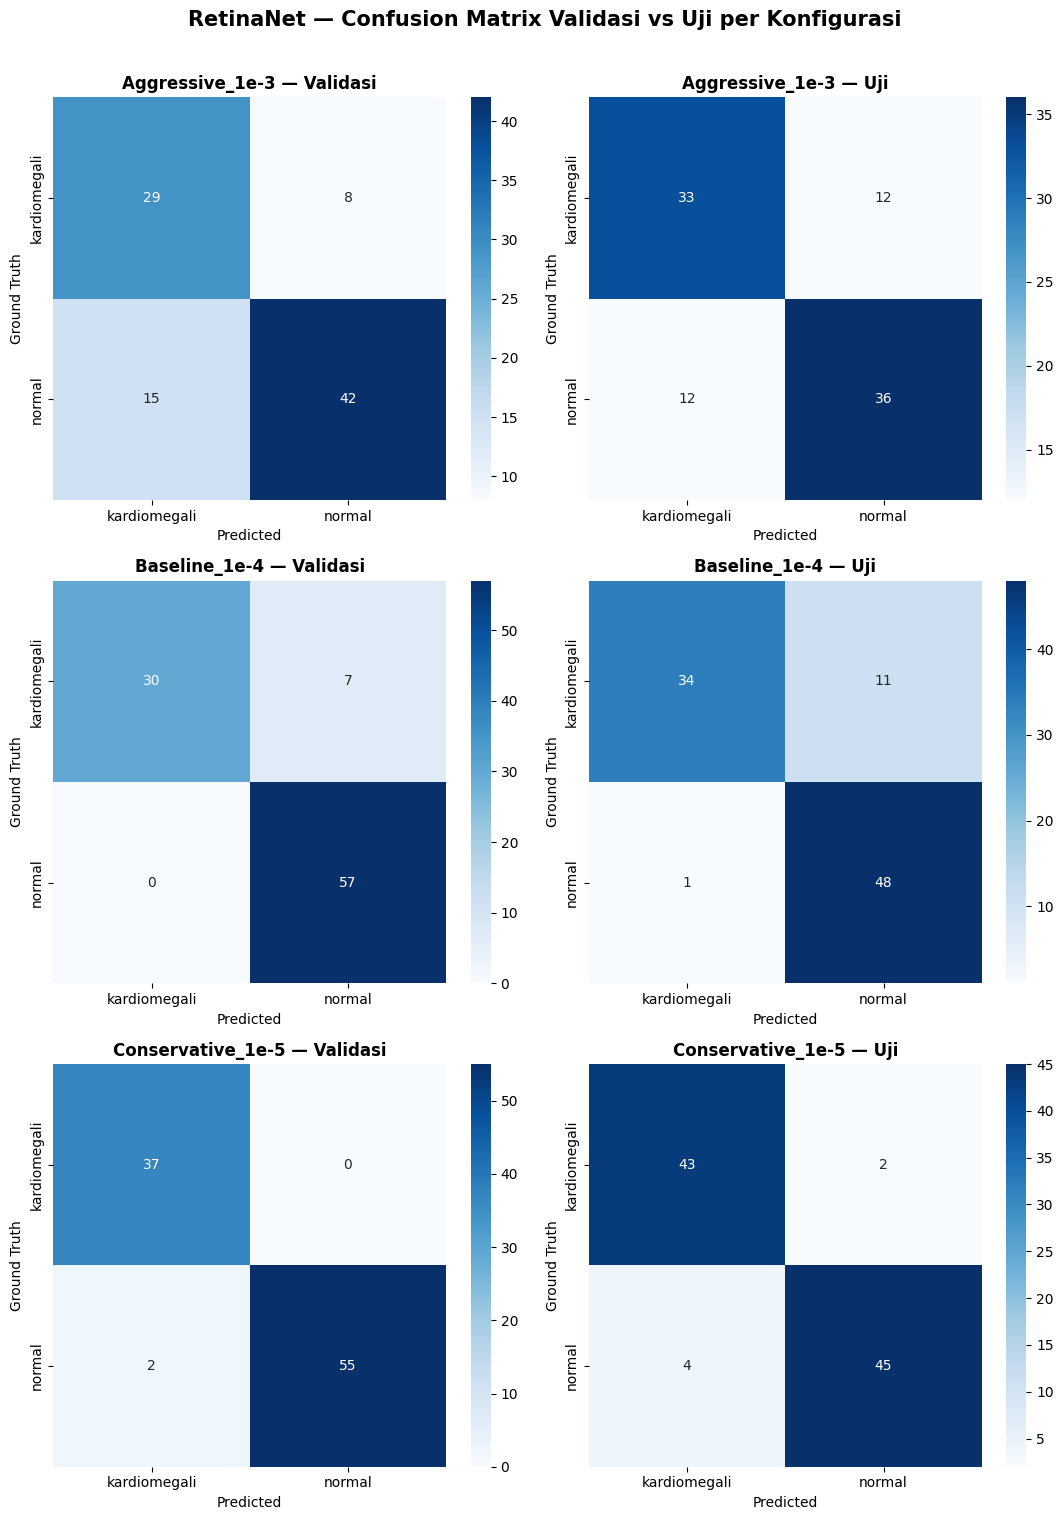

In [26]:
scenarios = list(retina_results.keys())
fig, axes = plt.subplots(len(scenarios), 2, figsize=(11, 5*len(scenarios)))

for i, scenario in enumerate(scenarios):
    res = retina_results[scenario]
    sns.heatmap(res['cm_valid'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i,0])
    axes[i,0].set_title(f'{scenario} — Validasi', fontweight='bold')
    axes[i,0].set_xlabel('Predicted'); axes[i,0].set_ylabel('Ground Truth')

    sns.heatmap(res['cm_test'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i,1])
    axes[i,1].set_title(f'{scenario} — Uji', fontweight='bold')
    axes[i,1].set_xlabel('Predicted'); axes[i,1].set_ylabel('Ground Truth')

plt.suptitle('RetinaNet — Confusion Matrix Validasi vs Uji per Konfigurasi', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'retinanet_cm_grid_valid_test_per_config.png', dpi=150, bbox_inches='tight')
plt.show()

Confusion Matrix YOLOv8s (Validasi vs Uji per Konfigurasi)

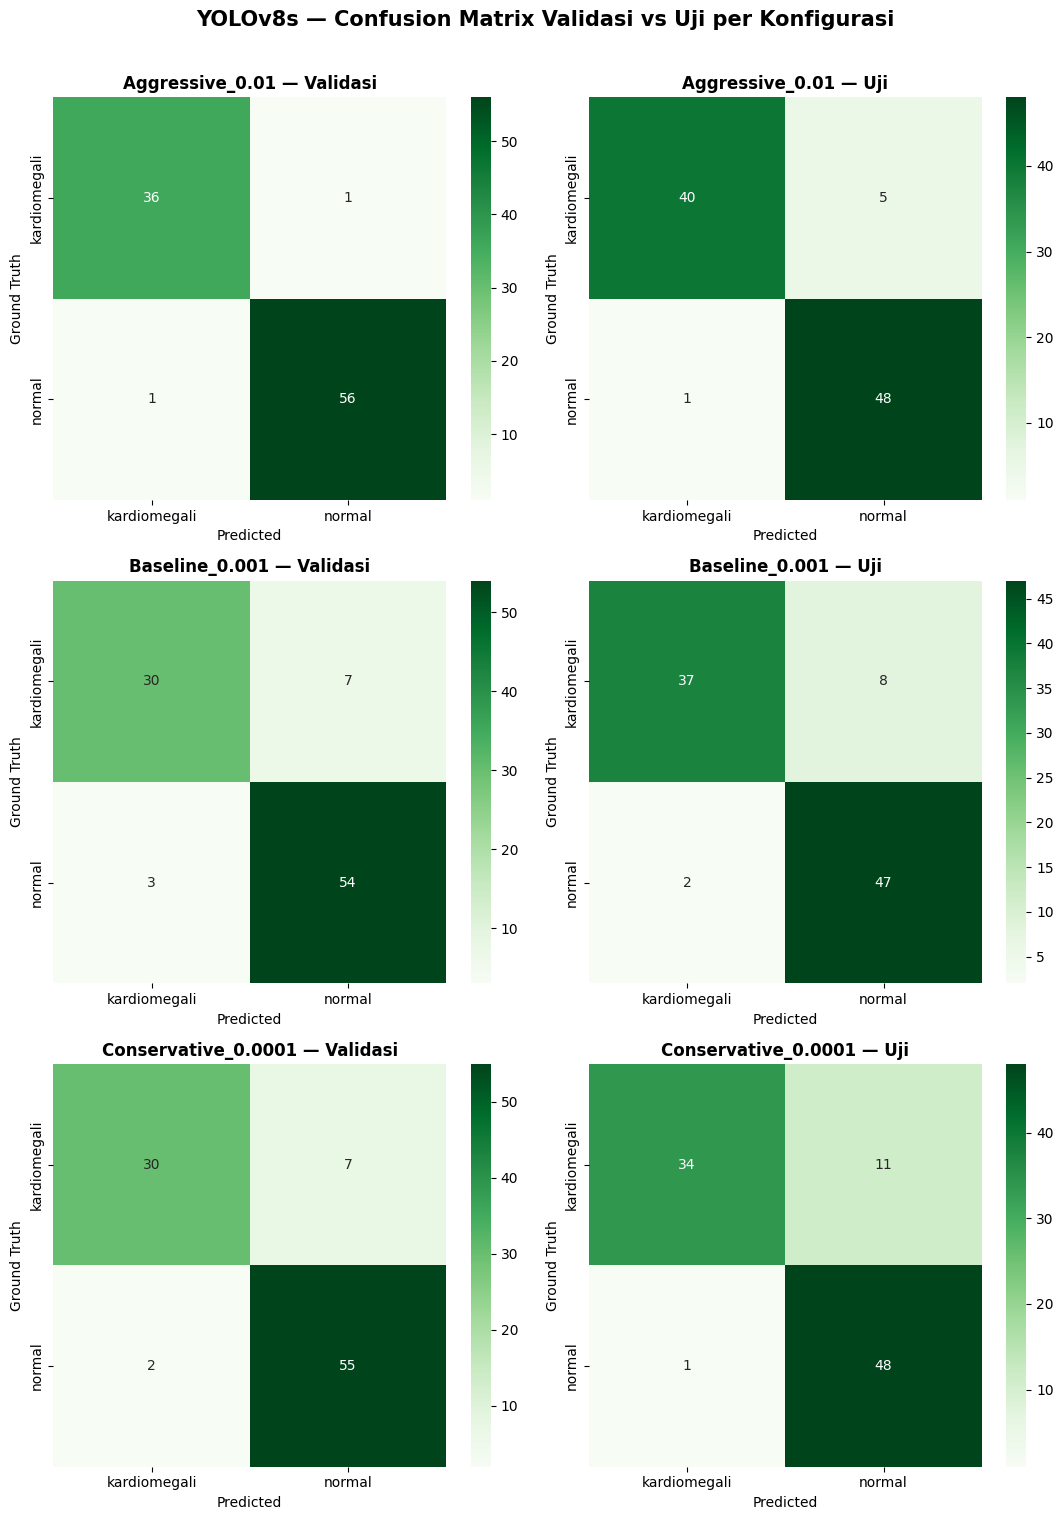

In [27]:
scenarios = list(yolo_results_dict.keys())
fig, axes = plt.subplots(len(scenarios), 2, figsize=(11, 5*len(scenarios)))

for i, scenario in enumerate(scenarios):
    res = yolo_results_dict[scenario]
    sns.heatmap(res['cm_valid'], annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i,0])
    axes[i,0].set_title(f'{scenario} — Validasi', fontweight='bold')
    axes[i,0].set_xlabel('Predicted'); axes[i,0].set_ylabel('Ground Truth')

    sns.heatmap(res['cm_test'], annot=True, fmt='d', cmap='Greens',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[i,1])
    axes[i,1].set_title(f'{scenario} — Uji', fontweight='bold')
    axes[i,1].set_xlabel('Predicted'); axes[i,1].set_ylabel('Ground Truth')

plt.suptitle('YOLOv8s — Confusion Matrix Validasi vs Uji per Konfigurasi', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'yolov8s_cm_grid_valid_test_per_config.png', dpi=150, bbox_inches='tight')
plt.show()

Bar Chart Perbandingan Metrik Antar Konfigurasi (berdampingan)

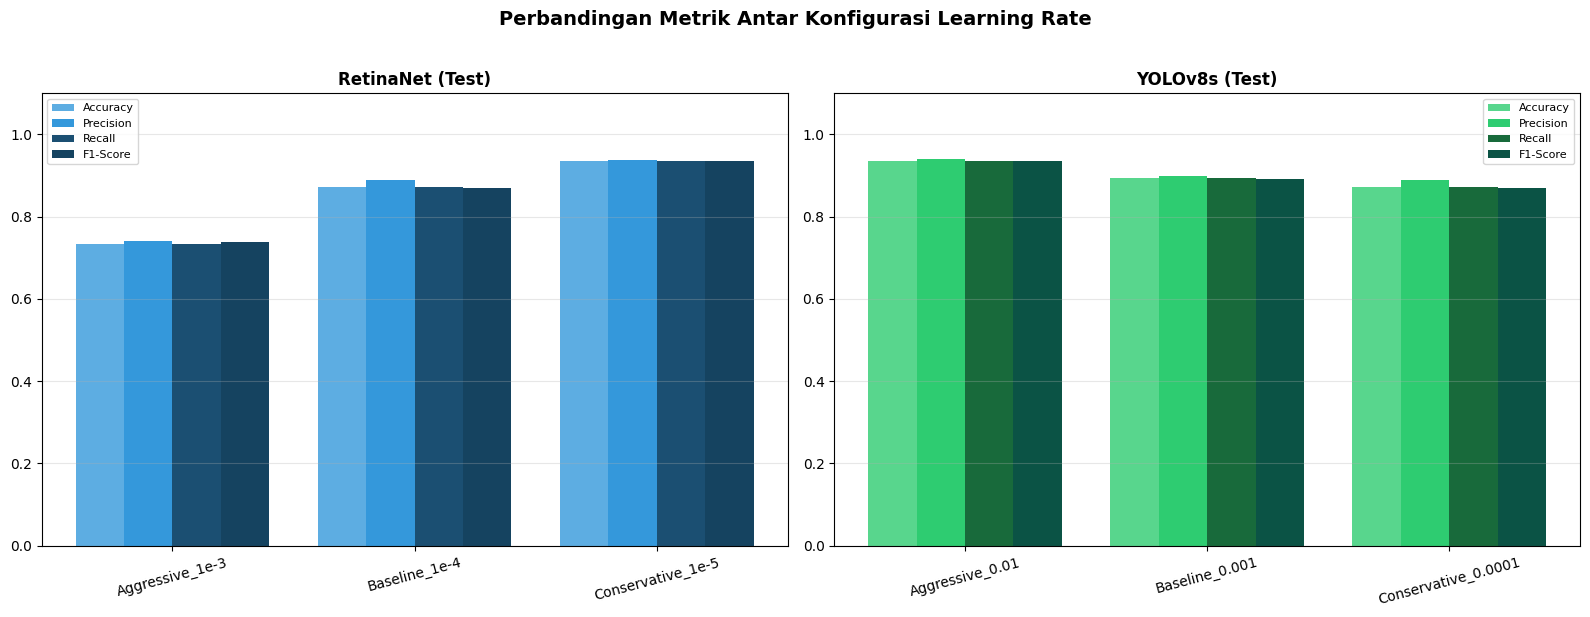

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metric_keys, metric_labels = ['accuracy','precision','recall','f1'], ['Accuracy','Precision','Recall','F1-Score']

x = np.arange(len(retina_results)); width = 0.2
colors_r = ['#5DADE2', '#3498DB', '#1B4F72', '#154360']
for i, (mk, ml, c) in enumerate(zip(metric_keys, metric_labels, colors_r)):
    vals = [retina_results[s]['metrics_test'][mk] for s in retina_results]
    axes[0].bar(x + (i-1.5)*width, vals, width, label=ml, color=c)
axes[0].set_xticks(x); axes[0].set_xticklabels(list(retina_results.keys()), rotation=15)
axes[0].set_ylim(0,1.1); axes[0].set_title('RetinaNet (Test)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

x = np.arange(len(yolo_results_dict))
colors_y = ['#58D68D', '#2ECC71', '#186A3B', '#0B5345']
for i, (mk, ml, c) in enumerate(zip(metric_keys, metric_labels, colors_y)):
    vals = [yolo_results_dict[s]['metrics_test'][mk] for s in yolo_results_dict]
    axes[1].bar(x + (i-1.5)*width, vals, width, label=ml, color=c)
axes[1].set_xticks(x); axes[1].set_xticklabels(list(yolo_results_dict.keys()), rotation=15)
axes[1].set_ylim(0,1.1); axes[1].set_title('YOLOv8s (Test)', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Metrik Antar Konfigurasi Learning Rate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'bar_chart_metrik_per_konfigurasi.png', dpi=150, bbox_inches='tight')
plt.show()

Bar Chart Perbandingan Akhir (Konfigurasi Terbaik RetinaNet vs YOLOv8s)

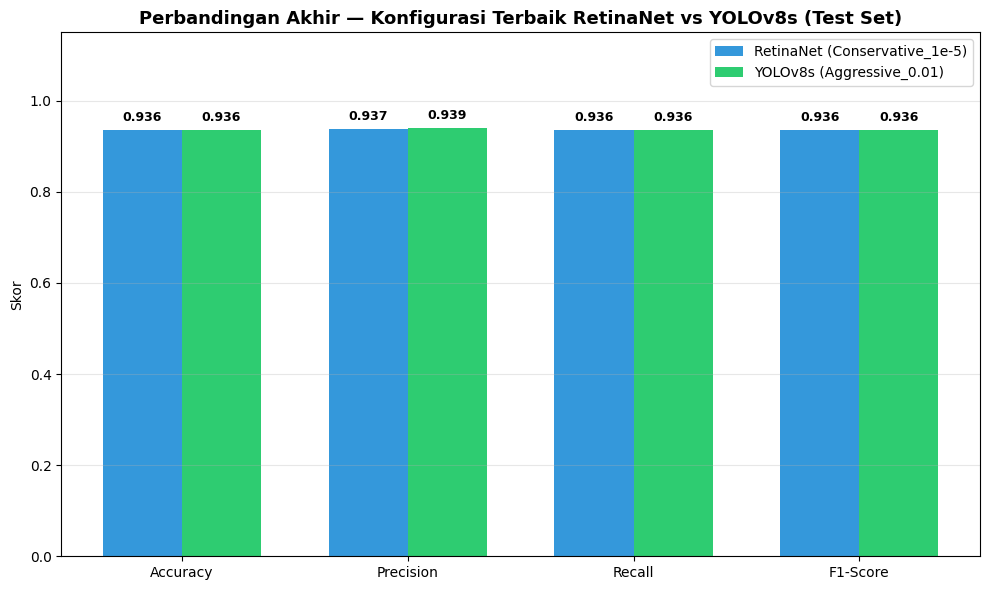

In [36]:
best_retina_name = max(retina_results, key=lambda s: retina_results[s]['metrics_test']['f1'])
best_yolo_name   = max(yolo_results_dict, key=lambda s: yolo_results_dict[s]['metrics_test']['f1'])

best_retina = retina_results[best_retina_name]['metrics_test']
best_yolo   = yolo_results_dict[best_yolo_name]['metrics_test']

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
retina_vals = [best_retina[k] for k in ['accuracy','precision','recall','f1']]
yolo_vals   = [best_yolo[k]   for k in ['accuracy','precision','recall','f1']]

x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, retina_vals, width, label=f'RetinaNet ({best_retina_name})', color='#3498DB')
b2 = ax.bar(x + width/2, yolo_vals,   width, label=f'YOLOv8s ({best_yolo_name})',     color='#2ECC71')

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.02, f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Skor')
ax.set_title('Perbandingan Akhir — Konfigurasi Terbaik RetinaNet vs YOLOv8s (Test Set)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'bar_chart_perbandingan_akhir.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# ============================================================
# TAMBAHAN — HITUNG mAP@50 & mAP@50-95 UNTUK RETINANET
# (mengisi kekosongan map50/map50_95 di retina_results)
# ============================================================
from torchmetrics.detection.mean_ap import MeanAveragePrecision

@torch.no_grad()
def calc_map_retinanet(ckpt_path, loader, device, conf_thresh=0.1):
    model = build_retinanet(NUM_CLASSES + 1, device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
    model.eval()

    map_preds, map_targets = [], []
    for images, targets in tqdm(loader, desc=f'mAP {ckpt_path.stem}', leave=False):
        if len(images) == 0 or len(targets) == 0:
            continue
        images = [img.to(device) for img in images]
        preds  = model(images)
        for pred, target in zip(preds, targets):
            gt_boxes  = target['boxes'].to(device)
            gt_labels = target['labels'].to(device)
            if len(gt_boxes) == 0:
                continue
            keep = pred['scores'] >= conf_thresh
            map_preds.append({
                'boxes' : pred['boxes'][keep].cpu(),
                'scores': pred['scores'][keep].cpu(),
                'labels': pred['labels'][keep].cpu()
            })
            map_targets.append({'boxes': gt_boxes.cpu(), 'labels': gt_labels.cpu()})

    metric = MeanAveragePrecision(iou_type='bbox')
    metric.update(map_preds, map_targets)
    r = metric.compute()
    return float(r['map_50'].item()), float(r['map'].item())


for scenario in retina_results:
    ckpt = EXPERIMENT_DIR / f'retinanet_{scenario}_best.pt'

    map50_v, map5095_v = calc_map_retinanet(ckpt, valid_loader_r, DEVICE, CONF_THRESH)
    map50_t, map5095_t = calc_map_retinanet(ckpt, test_loader_r,  DEVICE, CONF_THRESH)

    retina_results[scenario]['metrics_valid']['map50']    = map50_v
    retina_results[scenario]['metrics_valid']['map50_95'] = map5095_v
    retina_results[scenario]['metrics_test']['map50']     = map50_t
    retina_results[scenario]['metrics_test']['map50_95']  = map5095_t

    print(f'{scenario:<22}: Valid mAP@0.5={map50_v:.4f} | Test mAP@0.5={map50_t:.4f}')

print('\n✅ map50 & map50_95 sudah ditambahkan ke retina_results.')

Aggressive_1e-3       : Valid mAP@0.5=0.8536 | Test mAP@0.5=0.8025


Baseline_1e-4         : Valid mAP@0.5=0.9663 | Test mAP@0.5=0.9236


Conservative_1e-5     : Valid mAP@0.5=0.9872 | Test mAP@0.5=0.9510

✅ map50 & map50_95 sudah ditambahkan ke retina_results.


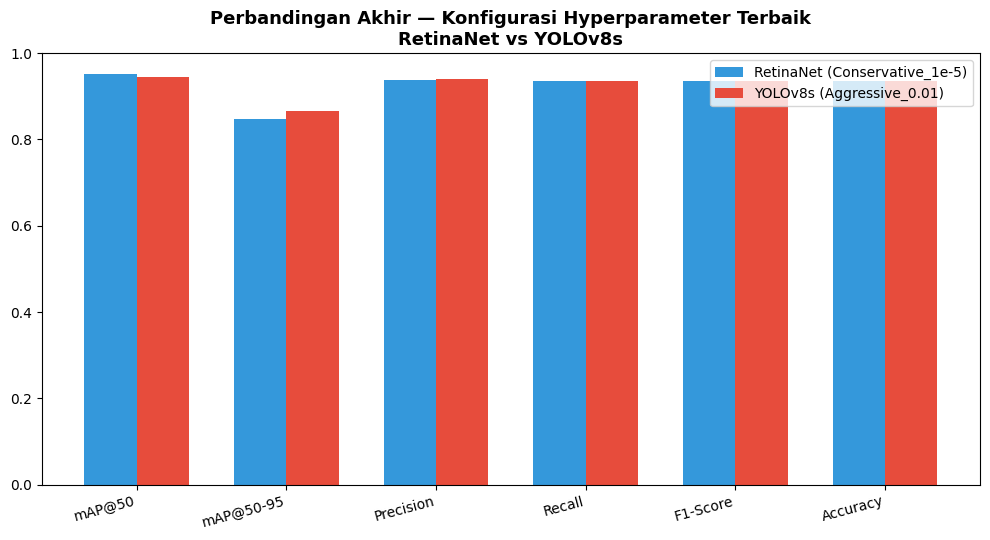

In [37]:
# ============================================================
# BAR CHART PERBANDINGAN AKHIR — KONFIGURASI TERBAIK
# RETINANET vs YOLOv8s (6 METRIK)
# ============================================================
best_retina_name = max(retina_results, key=lambda s: retina_results[s]['metrics_test']['f1'])
best_yolo_name   = max(yolo_results_dict, key=lambda s: yolo_results_dict[s]['metrics_test']['f1'])

best_retina = retina_results[best_retina_name]['metrics_test']
best_yolo   = yolo_results_dict[best_yolo_name]['metrics_test']

labels = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'F1-Score', 'Accuracy']

retina_vals = [
    best_retina['map50'],
    best_retina['map50_95'],
    best_retina['precision'],
    best_retina['recall'],
    best_retina['f1'],
    best_retina['accuracy'],
]
yolo_vals = [
    best_yolo['map50'],
    best_yolo['map50_95'],
    best_yolo['precision'],
    best_yolo['recall'],
    best_yolo['f1'],
    best_yolo['accuracy'],
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(x - width/2, retina_vals, width, label=f'RetinaNet ({best_retina_name})', color='#3498DB')
ax.bar(x + width/2, yolo_vals,   width, label=f'YOLOv8s ({best_yolo_name})',     color='#E74C3C')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylim(0, 1.0)
ax.set_title('Perbandingan Akhir — Konfigurasi Hyperparameter Terbaik\nRetinaNet vs YOLOv8s',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'bar_chart_perbandingan_akhir_6metrik.png', dpi=150, bbox_inches='tight')
plt.show()

Training Curve YOLOv8s per Konfigurasi (Loss + Performa)

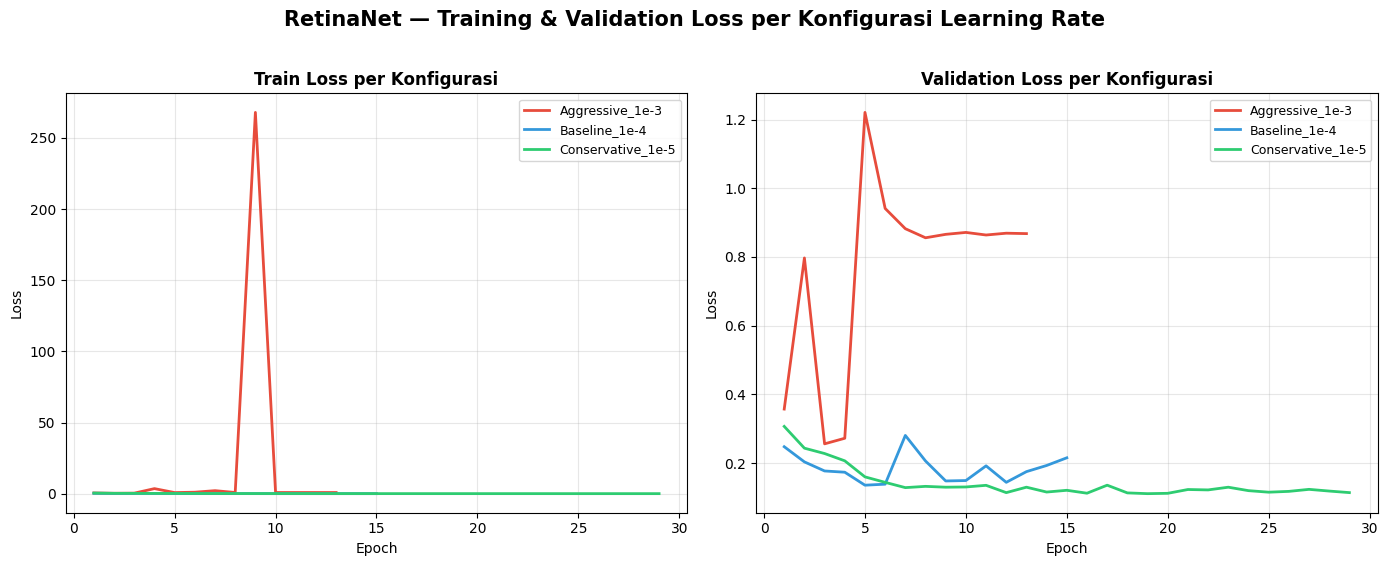

In [31]:
# ============================================================
# TRAINING CURVE RETINANET PER KONFIGURASI — LOSS
# ============================================================
RETINA_COLORS = [('Aggressive_1e-3', '#E74C3C'), ('Baseline_1e-4', '#3498DB'), ('Conservative_1e-5', '#2ECC71')]

retina_histories = {}
for scenario_name, _ in RETINA_COLORS:
    csv_path = EXPERIMENT_DIR / f'retinanet_{scenario_name}_history.csv'
    if csv_path.exists():
        retina_histories[scenario_name] = pd.read_csv(csv_path)
    else:
        print(f'❌ history tidak ditemukan untuk {scenario_name}: {csv_path}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for scenario_name, color in RETINA_COLORS:
    if scenario_name in retina_histories:
        df = retina_histories[scenario_name]
        axes[0].plot(df['epoch'], df['train_loss'], label=scenario_name, color=color, linewidth=2)
        axes[1].plot(df['epoch'], df['val_loss'],   label=scenario_name, color=color, linewidth=2)

axes[0].set_title('Train Loss per Konfigurasi', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Loss per Konfigurasi', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('RetinaNet — Training & Validation Loss per Konfigurasi Learning Rate', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'retinanet_training_loss_curve_all_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

Training Curve Retinanet per Konfigurasi (Loss + Performa)

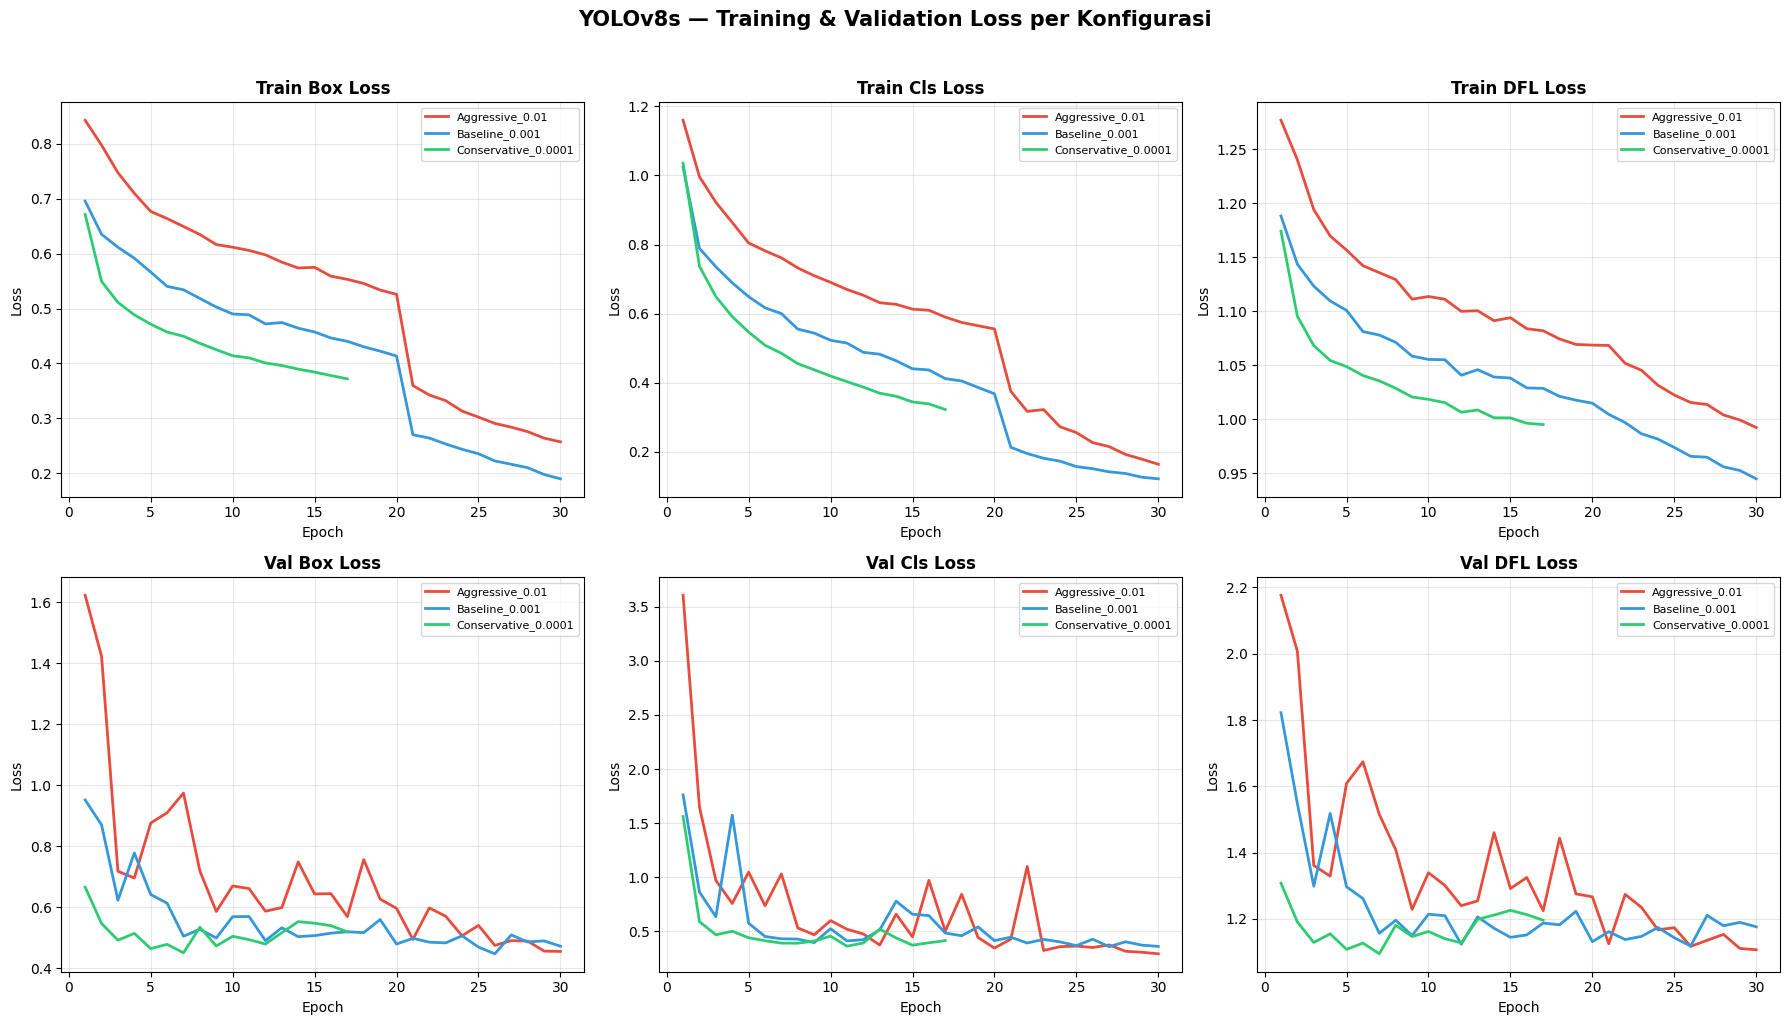

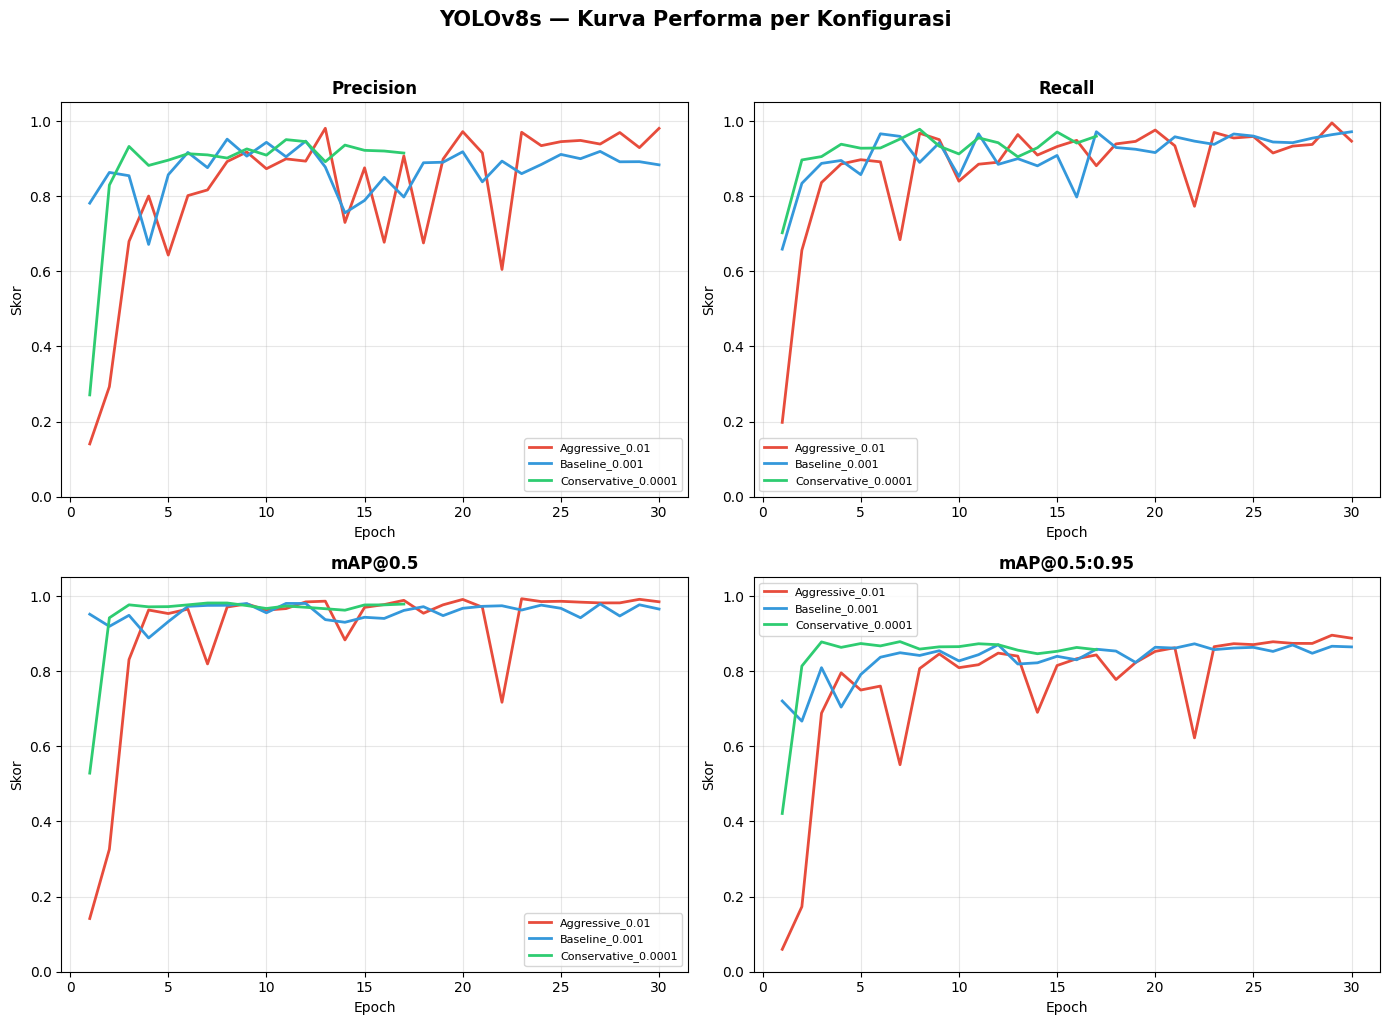

In [30]:
SCENARIOS = [('Aggressive_0.01', '#E74C3C'), ('Baseline_0.001', '#3498DB'), ('Conservative_0.0001', '#2ECC71')]

histories = {}
for scenario_name, _ in SCENARIOS:
    csv_path = EXPERIMENT_DIR / 'yolov8s' / scenario_name / 'results.csv'
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()
        histories[scenario_name] = df
    else:
        print(f'❌ results.csv tidak ditemukan untuk {scenario_name}: {csv_path}')

# --- Loss curve ---
loss_cols = [('train/box_loss','Train Box Loss'), ('train/cls_loss','Train Cls Loss'), ('train/dfl_loss','Train DFL Loss'),
             ('val/box_loss','Val Box Loss'), ('val/cls_loss','Val Cls Loss'), ('val/dfl_loss','Val DFL Loss')]
fig, axes = plt.subplots(2, 3, figsize=(18, 10)); axes = axes.flatten()
for ax, (col, title) in zip(axes, loss_cols):
    for scenario_name, color in SCENARIOS:
        if scenario_name in histories and col in histories[scenario_name].columns:
            df = histories[scenario_name]
            ax.plot(df['epoch'], df[col], label=scenario_name, color=color, linewidth=2)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('YOLOv8s — Training & Validation Loss per Konfigurasi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'yolov8s_training_loss_curve_all_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Performance curve ---
perf_cols = [('metrics/precision(B)','Precision'), ('metrics/recall(B)','Recall'),
             ('metrics/mAP50(B)','mAP@0.5'), ('metrics/mAP50-95(B)','mAP@0.5:0.95')]
fig, axes = plt.subplots(2, 2, figsize=(14, 10)); axes = axes.flatten()
for ax, (col, title) in zip(axes, perf_cols):
    for scenario_name, color in SCENARIOS:
        if scenario_name in histories and col in histories[scenario_name].columns:
            df = histories[scenario_name]
            ax.plot(df['epoch'], df[col], label=scenario_name, color=color, linewidth=2)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Epoch'); ax.set_ylabel('Skor')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('YOLOv8s — Kurva Performa per Konfigurasi', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EXPERIMENT_DIR / 'yolov8s_performance_curve_all_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

Tabel konfigurasi hyperparameter ke 2 model

In [33]:
# ============================================================
# TABEL KONFIGURASI HYPERPARAMETER — RETINANET & YOLOv8s
# ============================================================
retinanet_config_table = pd.DataFrame({
    'Hyperparameter': ['Backbone', 'Optimizer', 'LR Head', 'LR Backbone', 'Weight Decay',
                        'Batch Size', 'Image Size', 'Epochs', 'Early-Stop Patience', 'Freeze Backbone'],
    'Baseline (Awal)':       ['ResNet50-FPN', 'AdamW', '1e-4', '1e-5', '1e-4', 4, '512x512', 50, 10, 'Epoch 1-3'],
    'Aggressive':             ['ResNet50-FPN', 'AdamW', '1e-3', '1e-4', '1e-4', 4, '512x512', 30, 10, 'Epoch 1-3'],
    'Baseline (LR-Comparison)': ['ResNet50-FPN', 'AdamW', '1e-4', '1e-5', '1e-4', 4, '512x512', 30, 10, 'Epoch 1-3'],
    'Conservative':           ['ResNet50-FPN', 'AdamW', '1e-5', '1e-6', '1e-4', 4, '512x512', 30, 10, 'Epoch 1-3'],
})

yolov8s_config_table = pd.DataFrame({
    'Hyperparameter': ['Pretrained', 'Optimizer', 'lr0', 'lrf', 'Weight Decay',
                        'Warmup Epochs', 'Batch Size', 'Image Size', 'Epochs', 'Early-Stop Patience'],
    'Baseline (Awal)':       ['yolov8s.pt', 'AdamW', 0.001, 0.0001, 0.0005, 3, 16, 512, 50, 10],
    'Aggressive':             ['yolov8s.pt', 'AdamW', 0.01,  0.0001, 0.0005, 3, 16, 512, 30, 10],
    'Baseline (LR-Comparison)': ['yolov8s.pt', 'AdamW', 0.001, 0.0001, 0.0005, 3, 16, 512, 30, 10],
    'Conservative':           ['yolov8s.pt', 'AdamW', 0.0001,0.0001, 0.0005, 3, 16, 512, 30, 10],
})

# Simpan ke CSV untuk lampiran skripsi
retinanet_config_table.to_csv(EXPERIMENT_DIR / 'tabel_konfigurasi_retinanet.csv', index=False)
yolov8s_config_table.to_csv(EXPERIMENT_DIR / 'tabel_konfigurasi_yolov8s.csv', index=False)

print('TABEL 1 — KONFIGURASI HYPERPARAMETER RETINANET')
display(retinanet_config_table)

print('\nTABEL 2 — KONFIGURASI HYPERPARAMETER YOLOv8s')
display(yolov8s_config_table)

TABEL 1 — KONFIGURASI HYPERPARAMETER RETINANET


,Hyperparameter,Baseline (Awal),Aggressive,Baseline (LR-Comparison),Conservative
0,Backbone,ResNet50-FPN,ResNet50-FPN,ResNet50-FPN,ResNet50-FPN
1,Optimizer,AdamW,AdamW,AdamW,AdamW
2,LR Head,1e-4,1e-3,1e-4,1e-5
3,LR Backbone,1e-5,1e-4,1e-5,1e-6
4,Weight Decay,1e-4,1e-4,1e-4,1e-4
5,Batch Size,4,4,4,4
6,Image Size,512x512,512x512,512x512,512x512
7,Epochs,50,30,30,30
8,Early-Stop Patience,10,10,10,10
9,Freeze Backbone,Epoch 1-3,Epoch 1-3,Epoch 1-3,Epoch 1-3



TABEL 2 — KONFIGURASI HYPERPARAMETER YOLOv8s


,Hyperparameter,Baseline (Awal),Aggressive,Baseline (LR-Comparison),Conservative
0,Pretrained,yolov8s.pt,yolov8s.pt,yolov8s.pt,yolov8s.pt
1,Optimizer,AdamW,AdamW,AdamW,AdamW
2,lr0,0.001,0.01,0.001,0.0001
3,lrf,0.0001,0.0001,0.0001,0.0001
4,Weight Decay,0.0005,0.0005,0.0005,0.0005
5,Warmup Epochs,3,3,3,3
6,Batch Size,16,16,16,16
7,Image Size,512,512,512,512
8,Epochs,50,30,30,30
9,Early-Stop Patience,10,10,10,10
